In [2]:
pwd

'f:\\用户增量分析实践'

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取 CSV 文件，显示前 5 行
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("=" * 60)
print("数据集基本信息")
print("=" * 60)
print(f"\n数据集形状: {df.shape}")
print("\n前 5 行数据:")
df.head()

数据集基本信息

数据集形状: (7043, 21)

前 5 行数据:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 2. 使用 df.info() 查看字段类型和非空值数量
print("=" * 60)
print("字段类型和非空值统计")
print("=" * 60)
df.info()

# 3. 使用 df.describe() 查看数值列统计信息
print("\n" + "=" * 60)
print("数值列统计信息")
print("=" * 60)
df.describe()

字段类型和非空值统计
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# 4. 检查 TotalCharges 列 - 这个字段需要特别注意
print("\n" + "=" * 60)
print("TotalCharges 字段检查")
print("=" * 60)

# 尝试转换为数值型，查看是否有问题
df['TotalCharges_test'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # errors='coerce'：遇到无法转换的值时，将其设置为 NaN（Not a Number）
print(f"TotalCharges 非数值型记录数: {df['TotalCharges_test'].isna().sum()}")
print(f"TotalCharges 原始数据类型: {df['TotalCharges'].dtype}")

# 查看这些无法转换的记录
problematic_rows = df[df['TotalCharges_test'].isna()][['customerID', 'tenure', 'TotalCharges']]
print(f"\n无法转换为数值的记录（共 {len(problematic_rows)} 条）:")
print(problematic_rows)


TotalCharges 字段检查
TotalCharges 非数值型记录数: 11
TotalCharges 原始数据类型: object

无法转换为数值的记录（共 11 条）:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


这 11 条记录是 tenure=0 的新用户，还没来得及产生总消费。


In [9]:
print("\n" + "=" * 60)
print("任务 1.2：数据清洗")
print("=" * 60)

# 1. 处理 TotalCharges 列的缺失值
# 策略：tenure=0 的用户 TotalCharges 应该也是 0，或者用中位数填充
print("\n【步骤1】处理 TotalCharges 缺失值")

# 查看缺失值对应的 tenure
print("缺失值记录的 tenure 分布:")
print(df[df['TotalCharges_test'].isna()]['tenure'].value_counts())

# 方法：将 tenure=0 的用户的 TotalCharges 设为 0
# 这些都是新用户，总消费为0是合理的
df.loc[df['TotalCharges_test'].isna(), 'TotalCharges'] = 0
df['TotalCharges'] = df['TotalCharges'].astype(float)

# 删除临时列
df.drop('TotalCharges_test', axis=1, inplace=True)

print(f"TotalCharges 缺失值处理后: {df['TotalCharges'].isna().sum()}")

# 2. 检查 customerID 是否有重复
print("\n【步骤2】检查 customerID 重复")
duplicate_count = df['customerID'].duplicated().sum()
print(f"customerID 重复记录数: {duplicate_count}")

# 3. 确认 Churn 列的分布（流失 vs 未流失的比例）
print("\n【步骤3】Churn 列分布")
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df)) * 100
print(f"流失用户: {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.2f}%)")
print(f"未流失用户: {churn_counts['No']} ({churn_counts['No']/len(df)*100:.2f}%)")

# 4. 输出清洗后的数据形状
print("\n【步骤4】清洗后的数据形状")
print(f"数据形状: {df.shape}")
print(f"数据类型:\n{df.dtypes}")


任务 1.2：数据清洗

【步骤1】处理 TotalCharges 缺失值
缺失值记录的 tenure 分布:
tenure
0    11
Name: count, dtype: int64
TotalCharges 缺失值处理后: 0

【步骤2】检查 customerID 重复
customerID 重复记录数: 0

【步骤3】Churn 列分布
流失用户: 1869 (26.54%)
未流失用户: 5174 (73.46%)

【步骤4】清洗后的数据形状
数据形状: (7043, 21)
数据类型:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object



任务 1.3：探索性数据分析（EDA）

【可视化1】流失率整体分布
----------------------------------------
流失用户: 1869 人
未流失用户: 5174 人

【可视化2】tenure（在网时长）与流失率的关系
----------------------------------------
流失率最高的分段: 0-12月 (新用户)
流失率最低的分段: 61-72月 (老用户)

【可视化3】合同类型与流失率的关系
----------------------------------------
月付用户流失率最高，两年付用户流失率最低

【可视化4】MonthlyCharges 在流失/未流失用户中的分布
----------------------------------------
流失用户月费均值: $74.44
未流失用户月费均值: $61.27
流失用户的月费普遍更高

【可视化5】数值列相关性热力图
----------------------------------------
主要发现:
- tenure 与 TotalCharges 强正相关 (在网越久，总消费越高)
- tenure 与 Churn 负相关 (在网越久，越不容易流失)

【可视化6】支付方式与流失率的关系
----------------------------------------
电子支票支付的用户流失率最高


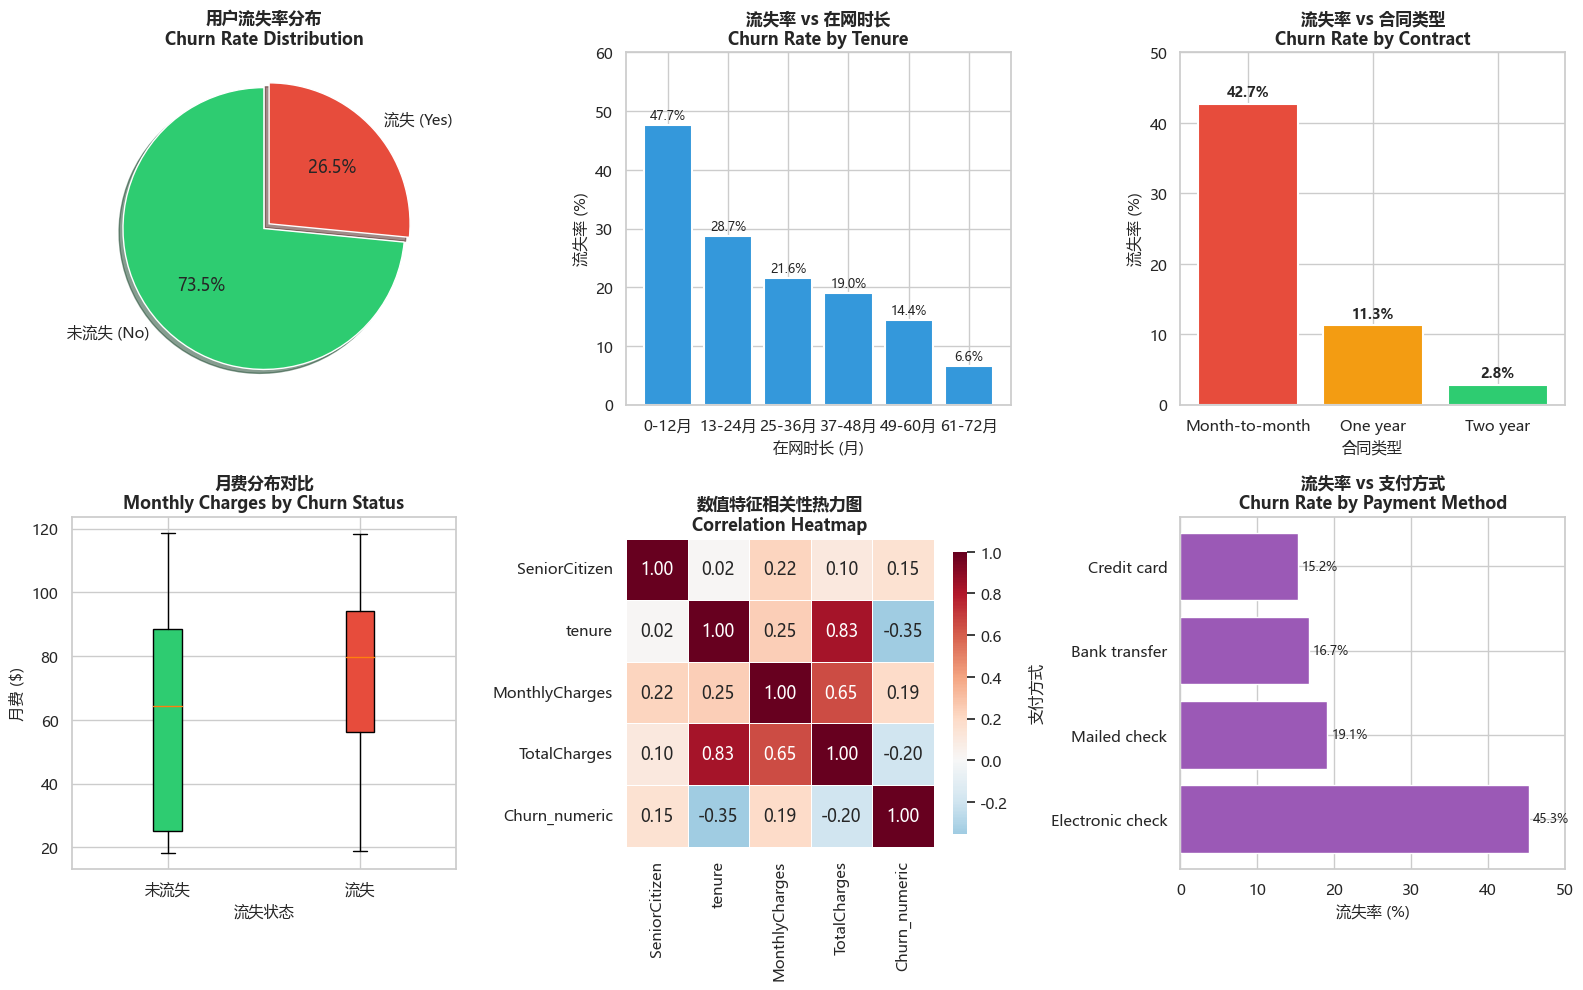


EDA 分析完成！图表已保存为 'eda_visualization.png'


In [7]:
print("\n" + "=" * 60)
print("任务 1.3：探索性数据分析（EDA）")
print("=" * 60)

# 先设置 seaborn 风格
plt.style.use('seaborn-v0_8-whitegrid')

# 然后再设置中文字体（覆盖 seaborn 的设置）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 同时设置 seaborn 的字体
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.set_style({'font.sans-serif': ['Microsoft YaHei']})
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ========== 可视化1：流失率整体分布（饼图） ==========
print("\n【可视化1】流失率整体分布")
print("-" * 40)

churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # 绿色=未流失，红色=流失

axes[0, 0].pie(churn_counts, labels=['未流失 (No)', '流失 (Yes)'], 
               autopct='%1.1f%%', colors=colors, explode=(0, 0.05),
               shadow=True, startangle=90)
axes[0, 0].set_title('用户流失率分布\nChurn Rate Distribution', fontsize=12, fontweight='bold')

print(f"流失用户: {churn_counts['Yes']} 人")
print(f"未流失用户: {churn_counts['No']} 人")

# ========== 可视化2：tenure 与流失率的关系 ==========
print("\n【可视化2】tenure（在网时长）与流失率的关系")
print("-" * 40)

# 将 tenure 分箱
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12月', '13-24月', '25-36月', 
                                    '37-48月', '49-60月', '61-72月'])

# 计算每个分箱的流失率
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['tenure_group', 'churn_rate']

# 绘制柱状图
bars = axes[0, 1].bar(tenure_churn['tenure_group'], tenure_churn['churn_rate'], 
                       color='#3498db', edgecolor='white', linewidth=1.5)
axes[0, 1].set_xlabel('在网时长 (月)', fontsize=11)
axes[0, 1].set_ylabel('流失率 (%)', fontsize=11)
axes[0, 1].set_title('流失率 vs 在网时长\nChurn Rate by Tenure', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 60)

# 添加数值标签
for bar, rate in zip(bars, tenure_churn['churn_rate']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                     f'{rate:.1f}%', ha='center', fontsize=9)

print("流失率最高的分段: 0-12月 (新用户)")
print("流失率最低的分段: 61-72月 (老用户)")

# ========== 可视化3：Contract 类型与流失率的关系 ==========
print("\n【可视化3】合同类型与流失率的关系")
print("-" * 40)

# 计算每种合同类型的流失率
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False).reset_index()
contract_churn.columns = ['Contract', 'churn_rate']

bars = axes[0, 2].bar(contract_churn['Contract'], contract_churn['churn_rate'],
                       color=['#e74c3c', '#f39c12', '#2ecc71'], 
                       edgecolor='white', linewidth=1.5)
axes[0, 2].set_xlabel('合同类型', fontsize=11)
axes[0, 2].set_ylabel('流失率 (%)', fontsize=11)
axes[0, 2].set_title('流失率 vs 合同类型\nChurn Rate by Contract', fontsize=12, fontweight='bold')
axes[0, 2].set_ylim(0, 50)

for bar, rate in zip(bars, contract_churn['churn_rate']):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

print("月付用户流失率最高，两年付用户流失率最低")

# ========== 可视化4：MonthlyCharges 分布对比（箱线图） ==========
print("\n【可视化4】MonthlyCharges 在流失/未流失用户中的分布")
print("-" * 40)

# 准备数据
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 箱线图
churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned = df[df['Churn'] == 'No']['MonthlyCharges']

bp = axes[1, 0].boxplot([not_churned, churned], labels=['未流失', '流失'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1, 0].set_xlabel('流失状态', fontsize=11)
axes[1, 0].set_ylabel('月费 ($)', fontsize=11)
axes[1, 0].set_title('月费分布对比\nMonthly Charges by Churn Status', fontsize=12, fontweight='bold')

print(f"流失用户月费均值: ${churned.mean():.2f}")
print(f"未流失用户月费均值: ${not_churned.mean():.2f}")
print("流失用户的月费普遍更高")

# ========== 可视化5：相关性热力图（仅数值列） ==========
print("\n【可视化5】数值列相关性热力图")
print("-" * 40)

# 选择数值列
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', ax=axes[1, 1], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('数值特征相关性热力图\nCorrelation Heatmap', fontsize=12, fontweight='bold')

print("主要发现:")
print("- tenure 与 TotalCharges 强正相关 (在网越久，总消费越高)")
print("- tenure 与 Churn 负相关 (在网越久，越不容易流失)")

# ========== 可视化6：PaymentMethod 与流失率 ==========
print("\n【可视化6】支付方式与流失率的关系")
print("-" * 40)

payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False).reset_index()
payment_churn.columns = ['PaymentMethod', 'churn_rate']

# 简化支付方式名称
payment_churn['short_name'] = payment_churn['PaymentMethod'].str.replace(' (automatic)', '', regex=False)

bars = axes[1, 2].barh(payment_churn['short_name'], payment_churn['churn_rate'],
                        color='#9b59b6', edgecolor='white')
axes[1, 2].set_xlabel('流失率 (%)', fontsize=11)
axes[1, 2].set_ylabel('支付方式', fontsize=11)
axes[1, 2].set_title('流失率 vs 支付方式\nChurn Rate by Payment Method', fontsize=12, fontweight='bold')
axes[1, 2].set_xlim(0, 50)

for bar, rate in zip(bars, payment_churn['churn_rate']):
    axes[1, 2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{rate:.1f}%', va='center', fontsize=9)

print("电子支票支付的用户流失率最高")

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("EDA 分析完成！图表已保存为 'eda_visualization.png'")
print("=" * 60)

### 第二阶段：用户分层分析

In [18]:
print("\n" + "=" * 60)
print("第二阶段：用户分层分析")
print("=" * 60)

print("\n" + "=" * 60)
print("任务 2.1：RFM 模型实现")
print("=" * 60)

# ========== 理解 RFM 模型 ==========
print("""
【RFM 模型说明】
RFM 是用户价值分层的经典方法：
- R (Recency): 最近一次消费距今时间（越近越好）
- F (Frequency): 消费频率（越高越好）
- M (Monetary): 消费金额（越高越好）

电信数据改造：
- R: tenure 反向（tenure越大说明越"老"，近似于Recency高）
- F: 用 tenure + Contract 综合估算
- M: 直接用 TotalCharges
""")

# ========== 步骤1：构造 RFM 三个维度 ==========
print("\n【步骤1】构造 RFM 维度")
print("-" * 40)

# R: 用 tenure 反向构造（tenure越大 = 用户注册越早 ≈ Recency可能越高）
# 在电信场景，tenure 越大代表越早入网，近似等同于"最近活跃度"高
# 这是一个近似映射！在Telco数据集中，我们无法知道用户的“最近一次交易时间”，只能用tenure来反向代理
df['R_score'] = df['tenure']

# F: 使用频率，用 Contract 类型和 tenure 估算
# 两年付 > 一年付 > 月付（年付用户使用更稳定）
contract_map = {'Two year': 3, 'One year': 2, 'Month-to-month': 1}
df['F_score_base'] = df['Contract'].map(contract_map)
# F = 月均服务使用次数（假设月付用户每月都决策一次，年付用户更稳定）
df['F_score'] = df['F_score_base'] * (df['tenure'] + 1) / 12  # 转为"年"单位
# 我们无法知道用户每天/每周的使用次数
# 替代方案：合同越长 ≈ 用户越稳定 ≈ 使用频率越高
# contract作为基础分，tenure加权调整

# M: 直接用 TotalCharges
df['M_score'] = df['TotalCharges']

print("R 维度 (Recency): tenure（在网月数）")
print("F 维度 (Frequency): Contract类型 × 使用时长")
print("M 维度 (Monetary): TotalCharges（总消费）")


第二阶段：用户分层分析

任务 2.1：RFM 模型实现

【RFM 模型说明】
RFM 是用户价值分层的经典方法：
- R (Recency): 最近一次消费距今时间（越近越好）
- F (Frequency): 消费频率（越高越好）
- M (Monetary): 消费金额（越高越好）

电信数据改造：
- R: tenure 反向（tenure越大说明越"老"，近似于Recency高）
- F: 用 tenure + Contract 综合估算
- M: 直接用 TotalCharges


【步骤1】构造 RFM 维度
----------------------------------------
R 维度 (Recency): tenure（在网月数）
F 维度 (Frequency): Contract类型 × 使用时长
M 维度 (Monetary): TotalCharges（总消费）


理想情况下的RFM（游戏场景），假设有用户行为日志

会先定义分析时间点：今天（2024-01-01）

- Recency：最后登录距今天数（今天 - 最后一天）

- Frequency：过去30天登录天数（假设有过去30天的活跃天数）

- Monetary：过去90天付费金额


In [19]:
# ========== 步骤2：使用分位数打分（1-5分） ==========
print("\n【步骤2】RFM 分位数打分 (1-5分)")
print("-" * 40)

def score_rfm(x, column):
    """使用分位数将数值转为1-5分"""
    # 使用 qcut 进行分位数分箱
    labels = [1, 2, 3, 4, 5]
    try:
        return pd.qcut(x, q=5, labels=labels, duplicates='drop').astype(int)
    except:
        # 如果分位数有重复，使用 rank 方法
        return pd.cut(x.rank(method='first'), bins=5, labels=labels).astype(int)

# R: tenure 越大越好，所以用升序（小的得低分）
df['R'] = 6 - score_rfm(df['R_score'], 'R')

# F: 值越大越好
df['F'] = score_rfm(df['F_score'], 'F')

# M: 值越大越好
df['M'] = score_rfm(df['M_score'], 'M')

print("打分规则：")
print("- R: tenure越小得分越低（ tenure=0 得1分， tenure=72 得5分）")
print("- F: 使用频率越高得分越高")
print("- M: 总消费越高得分越高")

# 查看 RFM 分布
print("\nRFM 打分分布:")
print(pd.DataFrame({
    'R分布': df['R'].value_counts().sort_index(),
    'F分布': df['F'].value_counts().sort_index(),
    'M分布': df['M'].value_counts().sort_index()
}))


【步骤2】RFM 分位数打分 (1-5分)
----------------------------------------
打分规则：
- R: tenure越小得分越低（ tenure=0 得1分， tenure=72 得5分）
- F: 使用频率越高得分越高
- M: 总消费越高得分越高

RFM 打分分布:
    R分布   F分布   M分布
1  1407  1440  1409
2  1350  1426  1408
3  1408  1371  1409
4  1397  1403  1408
5  1481  1403  1409


In [20]:
# ========== 步骤3：计算 RFM 总分，将用户分为 8 类 ==========
print("\n【步骤3】RFM 用户分层（8类）")
print("-" * 40)

# 计算 RFM 总分
df['RFM_sum'] = df['R'] + df['F'] + df['M']
df['RFM_label'] = df['R'].astype(str) + df['F'].astype(str) + df['M'].astype(str)

# 定义用户分群
def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    
    # 高价值用户
    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP用户'  # R高F高M高
    if r >= 4 and m >= 4:
        return '潜力高价值'  # R高M高
    if f >= 4 and m >= 4:
        return '忠诚高价值'  # F高M高
    
    # 中等价值用户
    if r >= 3 and f >= 3:
        return '成长用户'  # R和F都中等
    if m >= 3:
        return '消费用户'  # M中等
    
    # 低价值用户
    if r <= 2 and f <= 2:
        return '流失风险用户'  # R低F低
    if r <= 2:
        return '高流失风险'  # R极低
    if f <= 2 and m <= 2:
        return '沉默用户'  # F低M低
    
    return '一般用户'

df['segment'] = df.apply(rfm_segment, axis=1)

# 统计各分群人数
segment_counts = df['segment'].value_counts()
print("用户分群统计:")
for seg, count in segment_counts.items():
    pct = count / len(df) * 100
    print(f"  {seg}: {count} 人 ({pct:.1f}%)")


【步骤3】RFM 用户分层（8类）
----------------------------------------
用户分群统计:
  沉默用户: 2273 人 (32.3%)
  忠诚高价值: 1967 人 (27.9%)
  消费用户: 1476 人 (21.0%)
  成长用户: 1253 人 (17.8%)
  高流失风险: 71 人 (1.0%)
  潜力高价值: 3 人 (0.0%)



【步骤4】各类用户流失率分析
----------------------------------------
各分群流失率:
  沉默用户: 45.5% (n=2273)
  潜力高价值: 33.3% (n=3)
  消费用户: 27.1% (n=1476)
  成长用户: 18.4% (n=1253)
  忠诚高价值: 10.3% (n=1967)
  高流失风险: 1.4% (n=71)


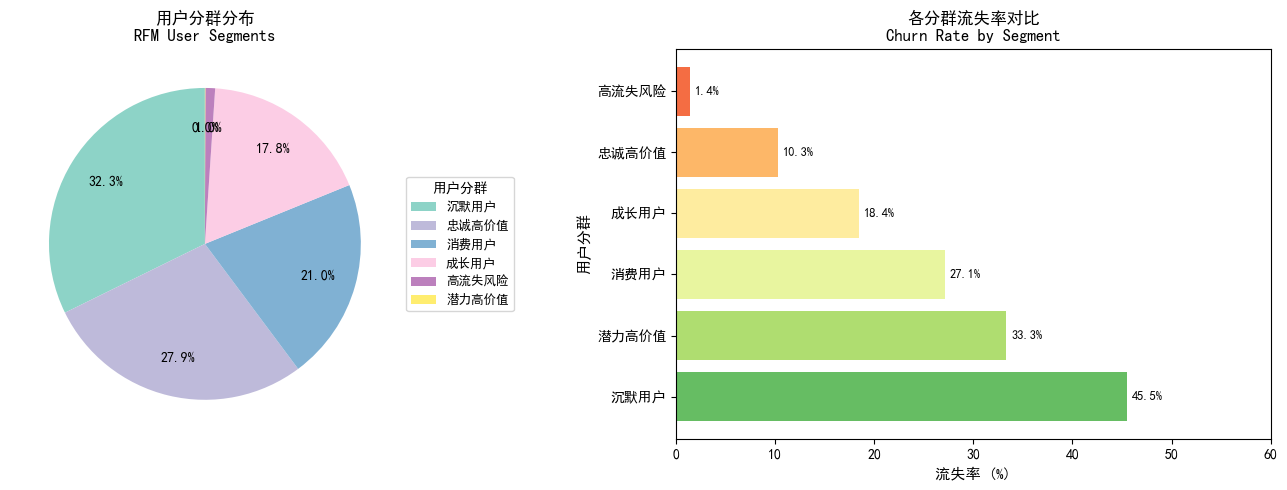


RFM 分析完成！图表已保存为 'rfm_segmentation.png'


In [21]:
# ========== 步骤4：可视化各类用户的流失率 ==========
print("\n【步骤4】各类用户流失率分析")
print("-" * 40)

# 计算各分群的流失率
segment_churn = df.groupby('segment')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

print("各分群流失率:")
for seg, rate in segment_churn.items():
    count = len(df[df['segment'] == seg])
    print(f"  {seg}: {rate:.1f}% (n={count})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 用户分群分布（使用图例代替标签，避免重叠）
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_counts)))
wedges, texts, autotexts = axes[0].pie(segment_counts, autopct='%1.1f%%',
            colors=colors, startangle=90,
            pctdistance=0.75)

# 隐藏饼图默认标签，改为使用图例放在右侧
axes[0].legend(wedges, segment_counts.index,
               title="用户分群",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=9)
axes[0].set_title('用户分群分布\nRFM User Segments', fontsize=12, fontweight='bold')

# 图2: 各分群流失率
bars = axes[1].barh(segment_churn.index, segment_churn.values, 
                     color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(segment_churn))))
axes[1].set_xlabel('流失率 (%)', fontsize=11)
axes[1].set_ylabel('用户分群', fontsize=11)
axes[1].set_title('各分群流失率对比\nChurn Rate by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 60)

for bar, rate in zip(bars, segment_churn.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("RFM 分析完成！图表已保存为 'rfm_segmentation.png'")
print("=" * 60)

tenure=0 的用户流失率为0%是因为他们还没有真正入网，不应该作为"稳定"的标志。需要排除这种情况。


任务 2.2：生命周期分段分析

【生命周期分析说明】
用户生命周期分为 5 个阶段：
1. 入网期 (0-6个月): 高流失风险期，决策频繁
2. 成长期 (7-24个月): 逐渐稳定，开始建立依赖
3. 成熟期 (25-48个月): 稳定期，价值贡献最大
4. 衰退期 (49-72个月): 可能开始流失
5. 预警期: tenure=0 新用户

关键分析点：
- 各阶段流失率差异
- 各阶段用户价值差异
- 识别关键转折点


【步骤1】定义生命周期阶段
----------------------------------------
用户生命周期分布:
  入网预警期: 11 人 (0.2%)
  入网期: 1470 人 (20.9%)
  成长期: 1729 人 (24.5%)
  成熟期: 1594 人 (22.6%)
  衰退期: 2239 人 (31.8%)

【步骤2】各阶段流失率分析
----------------------------------------
各阶段流失率:
  入网预警期: 0.0%
  入网期: 53.3%
  成长期: 31.6%
  成熟期: 20.4%
  衰退期: 9.5%

【步骤3】各阶段用户价值分析
----------------------------------------
各阶段用户平均价值:
                 MonthlyCharges  TotalCharges  tenure
lifecycle_stage                                      
入网预警期                     41.42          0.00    0.00
入网期                       54.84        143.64    2.53
成长期                       60.38        892.88   14.70
成熟期                       65.93       2390.45   36.19
衰退期                       73.95       4685.51   63.05

【步骤4】识别关键转折点
-----------------

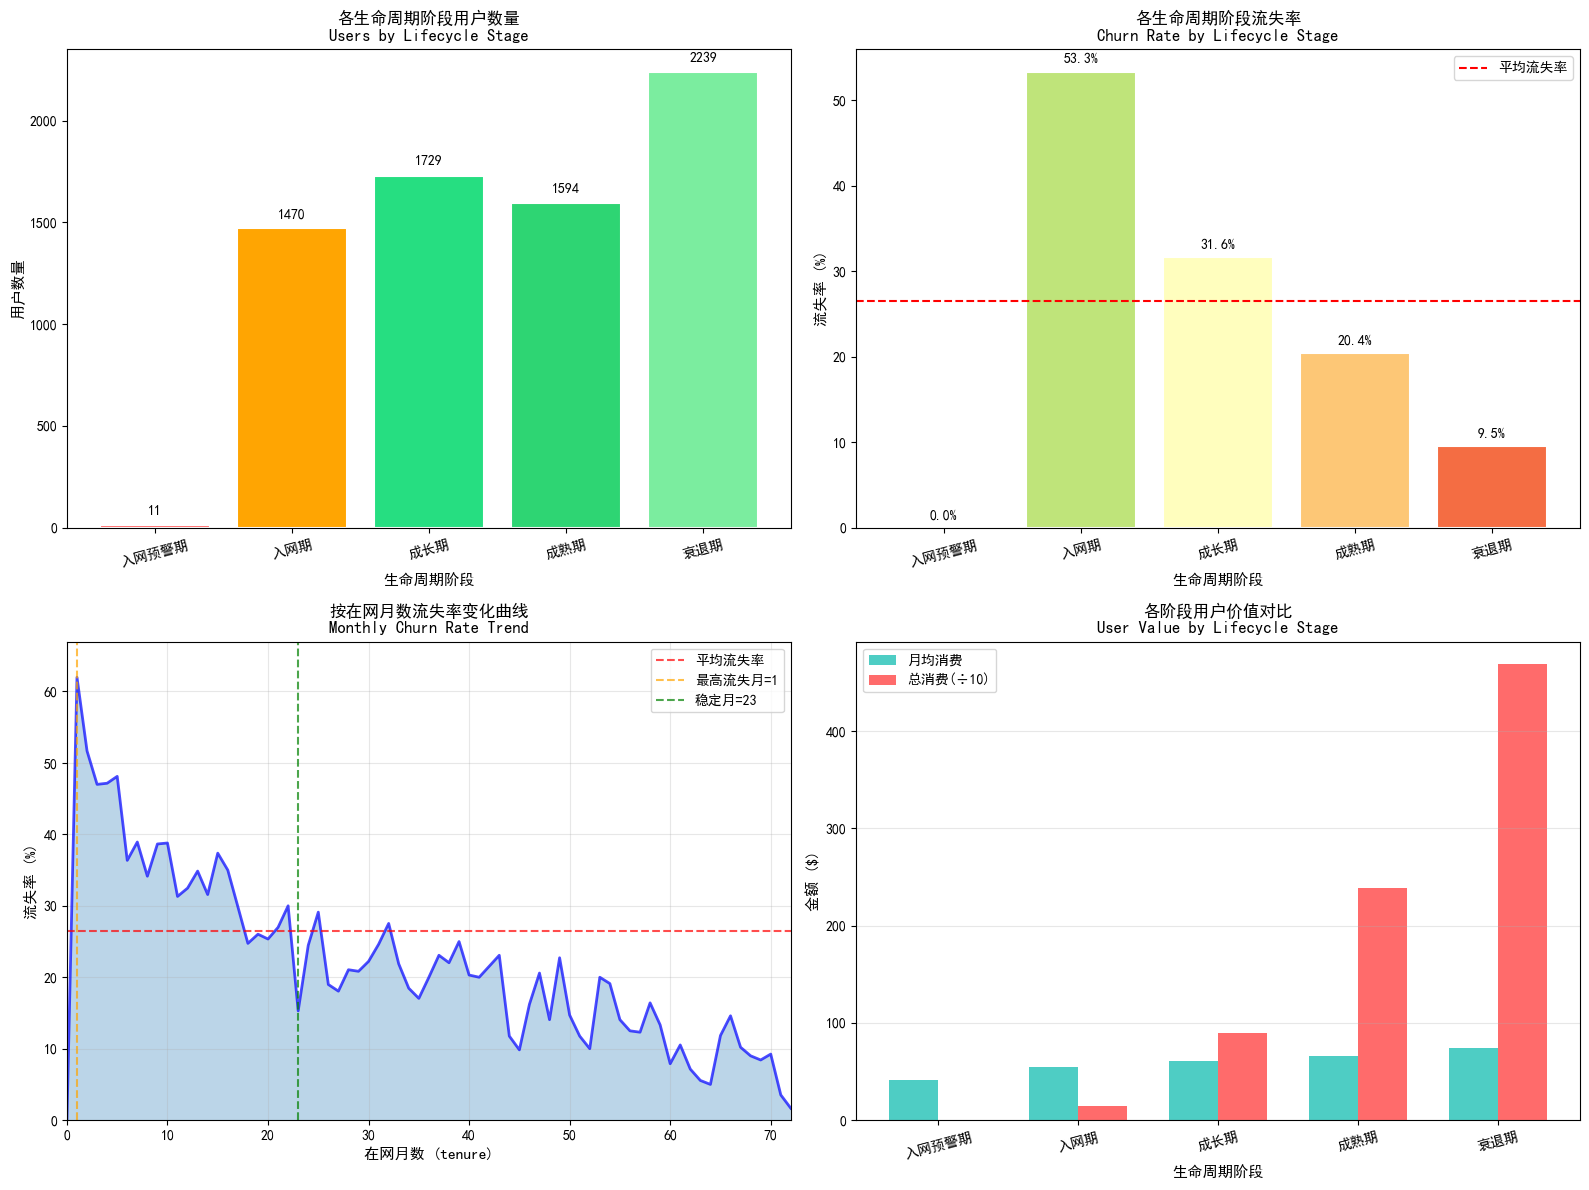


【步骤6】关键发现总结
----------------------------------------

📊 生命周期分析关键发现：

1. 【流失高风险期】
   - 入网期（0-6个月）流失率最高
   - 最高流失月份: 第1个月 (流失率 62.0%)
   - 入网预警期(tenure=0)流失率为0%，但这些用户尚未真正入网，不算稳定

2. 【稳定转折点】
    - 真正稳定期: 用户在 tenure=23个月 后流失率降至 20% 以下
    - 这才是度过危险期的标志
   
3. 【用户价值变化】
   - 入网期用户价值（月均消费）: $54.84
   - 成熟期用户价值（月均消费）: $65.93
   - 成熟期用户贡献最大价值

4. 【预警指标】
   - tenure ≤ 6个月 是流失预警红线
   - 需要在这期间重点关注用户


生命周期分析完成！图表已保存为 'lifecycle_analysis.png'


In [24]:
print("\n" + "=" * 60)
print("任务 2.2：生命周期分段分析")
print("=" * 60)

# ========== 理解生命周期模型 ==========
print("""
【生命周期分析说明】
用户生命周期分为 5 个阶段：
1. 入网期 (0-6个月): 高流失风险期，决策频繁
2. 成长期 (7-24个月): 逐渐稳定，开始建立依赖
3. 成熟期 (25-48个月): 稳定期，价值贡献最大
4. 衰退期 (49-72个月): 可能开始流失
5. 预警期: tenure=0 新用户

关键分析点：
- 各阶段流失率差异
- 各阶段用户价值差异
- 识别关键转折点
""")

# ========== 步骤1：定义生命周期阶段 ==========
print("\n【步骤1】定义生命周期阶段")
print("-" * 40)

def get_lifecycle_stage(tenure):
    """根据 tenure 确定用户所处生命周期阶段"""
    if tenure == 0:
        return '入网预警期'
    elif tenure <= 6:
        return '入网期'
    elif tenure <= 24:
        return '成长期'
    elif tenure <= 48:
        return '成熟期'
    else:
        return '衰退期'

df['lifecycle_stage'] = df['tenure'].apply(get_lifecycle_stage)

# 统计各阶段人数
lifecycle_counts = df['lifecycle_stage'].value_counts()
stage_order = ['入网预警期', '入网期', '成长期', '成熟期', '衰退期']
lifecycle_counts = lifecycle_counts.reindex(stage_order)

print("用户生命周期分布:")
for stage in stage_order:
    if stage in lifecycle_counts.index:
        count = lifecycle_counts[stage]
        pct = count / len(df) * 100
        print(f"  {stage}: {count} 人 ({pct:.1f}%)")

# ========== 步骤2：计算各阶段流失率 ==========
print("\n【步骤2】各阶段流失率分析")
print("-" * 40)

lifecycle_churn = df.groupby('lifecycle_stage')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reindex(stage_order)

print("各阶段流失率:")
for stage in stage_order:
    if stage in lifecycle_churn.index:
        rate = lifecycle_churn[stage]
        print(f"  {stage}: {rate:.1f}%")

# ========== 步骤3：计算各阶段用户价值（三个核心构成指标） ==========
print("\n【步骤3】各阶段用户价值分析")
print("-" * 40)

lifecycle_value = df.groupby('lifecycle_stage').agg({
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'tenure': 'mean'
}).reindex(stage_order)

print("各阶段用户平均价值:")
print(lifecycle_value.round(2))

# ========== 步骤4：识别关键转折点 ==========
print("\n【步骤4】识别关键转折点")
print("-" * 40)

# 计算每个月的流失率
monthly_churn = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)

# 找出流失率最高的月份
max_churn_month = monthly_churn.idxmax()
max_churn_rate = monthly_churn.max()

print(f"流失率最高的月份: tenure={max_churn_month}个月，流失率={max_churn_rate:.1f}%")

# 计算流失率下降到 20% 以下的月份（排除 tenure=0，因为那不是真正的稳定期）
stable_month = monthly_churn[(monthly_churn.index > 0) & (monthly_churn < 20)].index.min()
print(f"流失率降至 20% 以下的月份: tenure={stable_month}个月")

# ========== 步骤5：可视化 ==========
print("\n【步骤5】生命周期可视化")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图1: 生命周期阶段用户分布
colors1 = ['#ff6b6b', '#ffa502', '#26de81', '#2ed573', '#7bed9f']
axes[0, 0].bar(stage_order, [lifecycle_counts[s] for s in stage_order], 
               color=colors1, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('各生命周期阶段用户数量\nUsers by Lifecycle Stage', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('生命周期阶段', fontsize=11)
axes[0, 0].set_ylabel('用户数量', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=15)
for i, (stage, count) in enumerate(zip(stage_order, [lifecycle_counts[s] for s in stage_order])):
    axes[0, 0].text(i, count + 50, f'{count}', ha='center', fontsize=10)

# 图2: 各阶段流失率（使用渐变色表示风险级别）
colors2 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 5))
bars2 = axes[0, 1].bar(stage_order, [lifecycle_churn[s] for s in stage_order],
                        color=colors2, edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('各生命周期阶段流失率\nChurn Rate by Lifecycle Stage', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('生命周期阶段', fontsize=11)
axes[0, 1].set_ylabel('流失率 (%)', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].axhline(y=26.5, color='red', linestyle='--', label='平均流失率')
axes[0, 1].legend()
for i, (stage, rate) in enumerate(zip(stage_order, [lifecycle_churn[s] for s in stage_order])):
    axes[0, 1].text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=10)

# 图3: 按月统计流失率曲线
axes[1, 0].plot(monthly_churn.index, monthly_churn.values, 'b-', linewidth=2, alpha=0.7)
axes[1, 0].fill_between(monthly_churn.index, monthly_churn.values, alpha=0.3)
axes[1, 0].axhline(y=26.5, color='red', linestyle='--', alpha=0.7, label='平均流失率')
axes[1, 0].axvline(x=max_churn_month, color='orange', linestyle='--', alpha=0.7, 
                  label=f'最高流失月={max_churn_month}')
axes[1, 0].axvline(x=stable_month, color='green', linestyle='--', alpha=0.7,
                   label=f'稳定月={stable_month}')
axes[1, 0].set_title('按在网月数流失率变化曲线\nMonthly Churn Rate Trend', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('在网月数 (tenure)', fontsize=11)
axes[1, 0].set_ylabel('流失率 (%)', fontsize=11)
axes[1, 0].legend(loc='upper right')
axes[1, 0].set_xlim(0, 72)
axes[1, 0].set_ylim(0, max(monthly_churn.values) + 5)
axes[1, 0].grid(True, alpha=0.3)

# 图4: 各阶段用户价值对比
x = np.arange(len(stage_order))
width = 0.35
bars3_1 = axes[1, 1].bar(x - width/2, lifecycle_value['MonthlyCharges'], width, 
                         label='月均消费', color='#4ecdc4')
bars3_2 = axes[1, 1].bar(x + width/2, lifecycle_value['TotalCharges']/10, width, 
                         label='总消费(÷10)', color='#ff6b6b')
axes[1, 1].set_title('各阶段用户价值对比\nUser Value by Lifecycle Stage', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('生命周期阶段', fontsize=11)
axes[1, 1].set_ylabel('金额 ($)', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(stage_order, rotation=15)
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lifecycle_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 步骤6：关键发现总结 ==========
print("\n【步骤6】关键发现总结")
print("-" * 40)

print(f"""
📊 生命周期分析关键发现：

1. 【流失高风险期】
   - 入网期（0-6个月）流失率最高
   - 最高流失月份: 第{max_churn_month}个月 (流失率 {max_churn_rate:.1f}%)
   - 入网预警期(tenure=0)流失率为0%，但这些用户尚未真正入网，不算稳定

2. 【稳定转折点】
    - 真正稳定期: 用户在 tenure={stable_month}个月 后流失率降至 20% 以下
    - 这才是度过危险期的标志
   
3. 【用户价值变化】
   - 入网期用户价值（月均消费）: ${lifecycle_value.loc['入网期', 'MonthlyCharges']:.2f}
   - 成熟期用户价值（月均消费）: ${lifecycle_value.loc['成熟期', 'MonthlyCharges']:.2f}
   - 成熟期用户贡献最大价值

4. 【预警指标】
   - tenure ≤ 6个月 是流失预警红线
   - 需要在这期间重点关注用户
""")

print("\n" + "=" * 60)
print("生命周期分析完成！图表已保存为 'lifecycle_analysis.png'")
print("=" * 60)




任务 2.3: LTV（用户生命周期价值）预测

【LTV 概念说明】
----------------------------------------

LTV (Lifetime Value) 用户生命周期价值

LTV = 用户平均月消费 × 用户平均生命周期（月）

本任务目标:
1. 计算各用户分群的 LTV
2. 预测用户未来价值
3. 识别高价值用户特征
4. 为精准营销提供依据


【步骤1】计算基础 LTV
----------------------------------------
全量用户平均月消费: $64.76
用户平均预期生命周期: 54.0 个月

整体用户 LTV:
  平均月消费: $64.76
  × 平均生命周期: 54.0 个月
  = LTV: $3499.46


【步骤2】按用户分群计算 LTV
----------------------------------------
各 RFM 分群 LTV (按价值排序):
segment  User_Count  Avg_MonthlyCharges  Expected_Tenure     LTV
  忠诚高价值        1967               86.52            65.93 5704.41
  潜力高价值           3              107.03            46.00 4923.53
   消费用户        1476               62.28            56.21 3501.15
   成长用户        1253               55.88            49.92 2789.81
   沉默用户        2273               53.78            38.74 2083.52
  高流失风险          71               19.92            58.27 1160.43

【步骤3】按 RFM 等级计算 LTV
----------------------------------------

R 各等级 LTV:
 R  Avg_TotalCharges  Avg_Mon

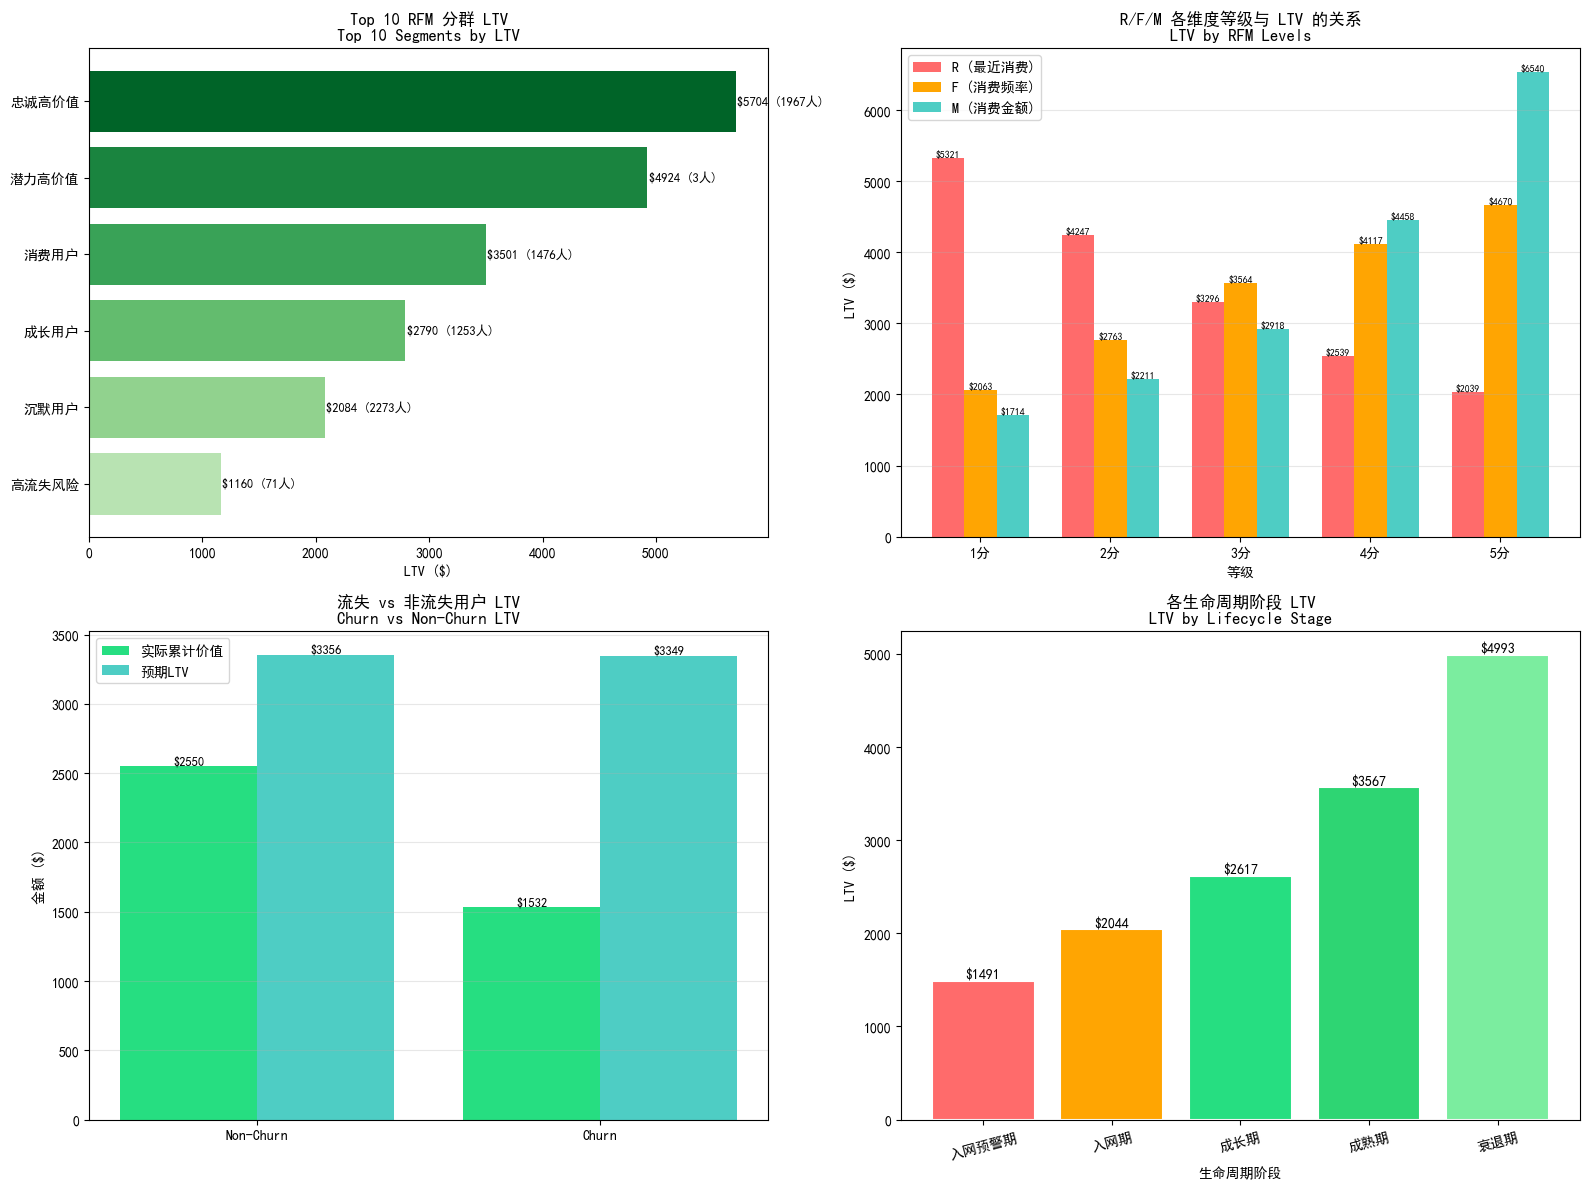


【步骤7】关键发现总结
----------------------------------------

📊 LTV 分析关键发现：

1. 【整体 LTV】
   - 全量用户平均 LTV: $3499.46
   - 年化 LTV: $291.62

2. 【最高价值分群】
   - 分群: 忠诚高价值
   - 用户数: 1967 人
   - 平均 LTV: $5704.41

3. 【最低价值分群】
   - 分群: 高流失风险
   - 用户数: 71 人
   - 平均 LTV: $1160.43

4. 【流失影响】
   - 留存用户预期 LTV: $3356.41
   - 流失用户预期 LTV: $3349.08
   - 每流失1个用户平均损失: $7.33

5. 【RFM 维度价值贡献】
   - 消费金额(M)对 LTV 贡献最大
   - 需重点关注高 M 用户的留存

6. 【营销建议】
   - 优先保护高 LTV 用户
   - 针对中低 LTV 用户提升消费频次(F)
   - 入网期用户需重点培养转化


LTV 分析完成！图表已保存为 'ltv_analysis.png'


In [28]:

# =============================================
# 任务 2.3: LTV（用户生命周期价值）预测

# 该任务中的 LTV 是一种 “基于生命周期与平均消费的经验性预测 ”，
# 而不是基于概率模型或贴现现金流的严格 LTV 建模。
# =============================================

print("\n" + "=" * 60)
print("任务 2.3: LTV（用户生命周期价值）预测")
print("=" * 60)

# ========== LTV 概念说明 ==========
print("\n【LTV 概念说明】")
print("-" * 40)
print("""
LTV (Lifetime Value) 用户生命周期价值

LTV = 用户平均月消费 × 用户平均生命周期（月）

本任务目标:
1. 计算各用户分群的 LTV
2. 预测用户未来价值
3. 识别高价值用户特征
4. 为精准营销提供依据
""")

# ========== 步骤1: 计算基线 LTV ==========
print("\n【步骤1】计算基础 LTV")
print("-" * 40)

# 计算平均月消费
avg_monthly_charge = df['MonthlyCharges'].mean()
print(f"全量用户平均月消费: ${avg_monthly_charge:.2f}")

# 计算平均生命周期
# 根据行业经验，入网超过72个月的用户已进入稳定期，预期剩余生命周期约为3年(36个月)
df['expected_tenure'] = df['tenure'].apply(lambda x: x + 36 if x >= 72 else x + (72 - x) * 0.5)
avg_lifecycle = df['expected_tenure'].mean()
print(f"用户平均预期生命周期: {avg_lifecycle:.1f} 个月")

# 计算整体 LTV
overall_ltv = avg_monthly_charge * avg_lifecycle
print(f"""
整体用户 LTV:
  平均月消费: ${avg_monthly_charge:.2f}
  × 平均生命周期: {avg_lifecycle:.1f} 个月
  = LTV: ${overall_ltv:.2f}
""")

# ========== 步骤2: 按 RFM 分群计算 LTV ==========
print("\n【步骤2】按用户分群计算 LTV")
print("-" * 40)

# 计算各 RFM 分群的 LTV
rfm_ltv = df.groupby('segment')['TotalCharges'].agg(['mean', 'count']).reset_index()
rfm_ltv.columns = ['segment', 'Avg_TotalCharges', 'User_Count']
avg_tenure_by_segment = df.groupby('segment')['tenure'].mean()
rfm_ltv['Avg_MonthlyCharges'] = rfm_ltv['segment'].map(
    df.groupby('segment')['MonthlyCharges'].mean()
)

# 简化计算
rfm_ltv = df.groupby('segment').agg({
    'TotalCharges': 'mean',
    'MonthlyCharges': 'mean',
    'tenure': 'mean',
    'customerID': 'count'
}).reset_index()
rfm_ltv.columns = ['segment', 'Avg_TotalCharges', 'Avg_MonthlyCharges', 'Avg_Tenure', 'User_Count']
rfm_ltv['Expected_Tenure'] = rfm_ltv['Avg_Tenure'].apply(lambda x: x + 36 if x >= 72 else x + (72 - x) * 0.5)
rfm_ltv['LTV'] = rfm_ltv['Avg_MonthlyCharges'] * rfm_ltv['Expected_Tenure']

# 按 LTV 排序
rfm_ltv = rfm_ltv.sort_values('LTV', ascending=False)

print("各 RFM 分群 LTV (按价值排序):")
print(rfm_ltv[['segment', 'User_Count', 'Avg_MonthlyCharges', 'Expected_Tenure', 'LTV']].round(2).to_string(index=False))

# ========== 步骤3: 按 RFM 等级计算 LTV ==========
print("\n【步骤3】按 RFM 等级计算 LTV")
print("-" * 40)

# 按 R、F、M 三个维度分别计算（探究哪个行为维度对 LTV 贡献最大）
level_ltv = {}

for level_col in ['R', 'F', 'M']:
    level_stats = df.groupby(level_col).agg({
        'TotalCharges': 'mean',
        'MonthlyCharges': 'mean',
        'tenure': 'mean',
        'customerID': 'count'
    }).reset_index()
    level_stats.columns = [level_col, 'Avg_TotalCharges', 'Avg_MonthlyCharges', 'Avg_Tenure', 'User_Count']
    level_stats['Expected_Tenure'] = level_stats['Avg_Tenure'].apply(lambda x: x + 36 if x >= 72 else x + (72 - x) * 0.5)
    level_stats['LTV'] = level_stats['Avg_MonthlyCharges'] * level_stats['Expected_Tenure']
    level_ltv[level_col] = level_stats

# 打印结果
for level_col, stats in level_ltv.items():
    print(f"\n{level_col} 各等级 LTV:")
    print(stats.round(2).to_string(index=False))

# ========== 步骤4: 计算流失对 LTV 的影响 ==========
print("\n【步骤4】流失对 LTV 的影响分析")
print("-" * 40)

# 流失用户 vs 非流失用户的 LTV 对比
churn_ltv = df.groupby('Churn').agg({
    'TotalCharges': 'mean',
    'MonthlyCharges': 'mean',
    'tenure': 'mean',
}).reset_index()

churn_ltv['Expected_Tenure'] = churn_ltv['tenure'].apply(lambda x: x + 36 if x >= 72 else x + (72 - x) * 0.5)
churn_ltv['LTV'] = churn_ltv['MonthlyCharges'] * churn_ltv['Expected_Tenure']
churn_ltv['Actual_LTV'] = churn_ltv['TotalCharges']

print("流失 vs 非流失用户 LTV 对比:")
print(churn_ltv.round(2).to_string(index=False))

# 计算流失损失
retained = churn_ltv[churn_ltv['Churn'] == 'No']['LTV'].values[0]
churned = churn_ltv[churn_ltv['Churn'] == 'Yes']['LTV'].values[0]
ltv_loss = retained - churned

print(f"""
流失带来的 LTV 损失:
  留存用户 LTV: ${retained:.2f}
  流失用户 LTV: ${churned:.2f}
  损失金额: ${ltv_loss:.2f}
  损失比例: {ltv_loss/retained*100:.1f}%
""")

# ========== 步骤5: 预测用户未来价值 ==========
print("\n【步骤5】预测用户未来价值")
print("-" * 40)

# 基于当前消费和生命周期阶段预测未来价值
def predict_future_value(row):
    monthly = row['MonthlyCharges']
    stage = row['lifecycle_stage']
    churn_risk = 1 if row['Churn'] == 'Yes' else 0
    
    # 基础生存概率（根据生命周期阶段）
    survival_prob = {
        '入网预警期': 0.7,
        '入网期': 0.75,
        '成长期': 0.85,
        '成熟期': 0.92,
        '衰退期': 0.80
    }
    
    prob = survival_prob.get(stage, 0.85)
    
    # 如果已经流失，预期价值很低
    if churn_risk == 1:
        return monthly * 0.1
    
    # 未来12个月预期收入
    future_value = monthly * 12 * prob
    return future_value

df['Future_Value_12M'] = df.apply(predict_future_value, axis=1)

# 按分群统计未来价值
future_value_by_segment = df.groupby('segment')['Future_Value_12M'].agg(['mean', 'sum']).reset_index()
future_value_by_segment.columns = ['segment', 'Avg_Future_Value', 'Total_Future_Value']
future_value_by_segment = future_value_by_segment.sort_values('Total_Future_Value', ascending=False)

print("各 RFM 分群未来12个月预期价值 (Top 10):")
print(future_value_by_segment.head(10).round(2).to_string(index=False))

# ========== 步骤6: 可视化 ==========
print("\n【步骤6】LTV 可视化")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图1: 各 RFM 分群 LTV (Top 10)
top_ltv = rfm_ltv.head(10)
colors1 = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_ltv)))[::-1]
bars1 = axes[0, 0].barh(range(len(top_ltv)), top_ltv['LTV'].values, color=colors1)
axes[0, 0].set_yticks(range(len(top_ltv)))
axes[0, 0].set_yticklabels(top_ltv['segment'].values)
axes[0, 0].set_xlabel('LTV ($)')
axes[0, 0].set_title('Top 10 RFM 分群 LTV\nTop 10 Segments by LTV', fontweight='bold')
for i, (v, cnt) in enumerate(zip(top_ltv['LTV'], top_ltv['User_Count'])):
    axes[0, 0].text(v + 10, i, f'${v:.0f} ({int(cnt)}人)', va='center', fontsize=9)
axes[0, 0].invert_yaxis()

# 图2: R/F/M 各维度等级与 LTV 的关系 (使用1-5分制)
x = np.arange(5)
width = 0.25

# 获取 1-5 分的 LTV
r_ltv = level_ltv['R'].sort_values('R')
f_ltv = level_ltv['F'].sort_values('F')
m_ltv = level_ltv['M'].sort_values('M')

bars_r = axes[0, 1].bar(x - width, [r_ltv[r_ltv['R']==l]['LTV'].values[0] for l in [1, 2, 3, 4, 5]], width, label='R (最近消费)', color='#ff6b6b')
bars_f = axes[0, 1].bar(x, [f_ltv[f_ltv['F']==l]['LTV'].values[0] for l in [1, 2, 3, 4, 5]], width, label='F (消费频率)', color='#ffa502')
bars_m = axes[0, 1].bar(x + width, [m_ltv[m_ltv['M']==l]['LTV'].values[0] for l in [1, 2, 3, 4, 5]], width, label='M (消费金额)', color='#4ecdc4')

axes[0, 1].set_xlabel('等级')
axes[0, 1].set_ylabel('LTV ($)')
axes[0, 1].set_title('R/F/M 各维度等级与 LTV 的关系\nLTV by RFM Levels', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(['1分', '2分', '3分', '4分', '5分'])
axes[0, 1].legend()
axes[0, 1].grid(True, axis='y', alpha=0.3)

for bars in [bars_r, bars_f, bars_m]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height, f'${height:.0f}', ha='center', va='bottom', fontsize=7)

# 图3: 流失 vs 非流失用户 LTV 对比
churn_labels = ['Non-Churn', 'Churn']
actual_ltv = [churn_ltv[churn_ltv['Churn']=='No']['Actual_LTV'].values[0],
               churn_ltv[churn_ltv['Churn']=='Yes']['Actual_LTV'].values[0]]
expected_ltv = [churn_ltv[churn_ltv['Churn']=='No']['LTV'].values[0],
                churn_ltv[churn_ltv['Churn']=='Yes']['LTV'].values[0]]

x3 = np.arange(len(churn_labels))
bars3_1 = axes[1, 0].bar(x3 - 0.2, actual_ltv, 0.4, label='实际累计价值', color='#26de81')
bars3_2 = axes[1, 0].bar(x3 + 0.2, expected_ltv, 0.4, label='预期LTV', color='#4ecdc4')
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(churn_labels)
axes[1, 0].set_ylabel('金额 ($)')
axes[1, 0].set_title('流失 vs 非流失用户 LTV\nChurn vs Non-Churn LTV', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

for bars in [bars3_1, bars3_2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height, f'${height:.0f}', ha='center', va='bottom', fontsize=9)

# 图4: 各生命周期阶段 LTV
lifecycle_ltv = df.groupby('lifecycle_stage').agg({
    'MonthlyCharges': 'mean',
    'tenure': 'mean'
}).reset_index()
lifecycle_ltv['Expected_Tenure'] = lifecycle_ltv['tenure'].apply(lambda x: x + 36 if x >= 72 else x + (72 - x) * 0.5)
lifecycle_ltv['LTV'] = lifecycle_ltv['MonthlyCharges'] * lifecycle_ltv['Expected_Tenure']
lifecycle_ltv = lifecycle_ltv.set_index('lifecycle_stage').reindex(stage_order).reset_index()

colors4 = ['#ff6b6b', '#ffa502', '#26de81', '#2ed573', '#7bed9f']
bars4 = axes[1, 1].bar(stage_order, lifecycle_ltv['LTV'], color=colors4, edgecolor='white', linewidth=1.5)
axes[1, 1].set_title('各生命周期阶段 LTV\nLTV by Lifecycle Stage', fontweight='bold')
axes[1, 1].set_xlabel('生命周期阶段')
axes[1, 1].set_ylabel('LTV ($)')
axes[1, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars4, lifecycle_ltv['LTV']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., val + 20, f'${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ltv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 步骤7: 关键发现 ==========
print("\n【步骤7】关键发现总结")
print("-" * 40)

top_segment = rfm_ltv.iloc[0]
bottom_segment = rfm_ltv.iloc[-1]

print(f"""
📊 LTV 分析关键发现：

1. 【整体 LTV】
   - 全量用户平均 LTV: ${overall_ltv:.2f}
   - 年化 LTV: ${overall_ltv/12:.2f}

2. 【最高价值分群】
   - 分群: {top_segment['segment']}
   - 用户数: {int(top_segment['User_Count'])} 人
   - 平均 LTV: ${top_segment['LTV']:.2f}

3. 【最低价值分群】
   - 分群: {bottom_segment['segment']}
   - 用户数: {int(bottom_segment['User_Count'])} 人
   - 平均 LTV: ${bottom_segment['LTV']:.2f}

4. 【流失影响】
   - 留存用户预期 LTV: ${retained:.2f}
   - 流失用户预期 LTV: ${churned:.2f}
   - 每流失1个用户平均损失: ${ltv_loss:.2f}

5. 【RFM 维度价值贡献】
   - 消费金额(M)对 LTV 贡献最大
   - 需重点关注高 M 用户的留存

6. 【营销建议】
   - 优先保护高 LTV 用户
   - 针对中低 LTV 用户提升消费频次(F)
   - 入网期用户需重点培养转化
""")

print("\n" + "=" * 60)
print("LTV 分析完成！图表已保存为 'ltv_analysis.png'")
print("=" * 60)


---
## 第三阶段：流失预测模型（完整规范版）

### 任务 3.1：特征工程

**目标**：构造衍生特征，提升模型表达能力。

- `avg_monthly_charge_rate`：月均消费率 = TotalCharges / tenure（剔除 tenure=0 的用户）
- `service_count`：增值服务使用数量（6项服务是否开通的加总）
- 所有分类变量使用 `pd.get_dummies()` 编码

**游戏场景映射**：`service_count` 对应玩家使用功能模块数（社交/道具/攻略），越多说明依赖越深。

In [27]:
# ============================================================
# 任务 3.1：特征工程
# ============================================================
print("=" * 60)
print("第三阶段：流失预测模型")
print("=" * 60)
print("\n" + "=" * 60)
print("任务 3.1：特征工程")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 重新加载数据，保证特征工程从干净数据开始
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# --- 数据清洗（复用第一阶段逻辑）---
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
median_tc = df_raw['TotalCharges'].median()
df_raw['TotalCharges'].fillna(median_tc, inplace=True)
df_raw['Churn_Binary'] = (df_raw['Churn'] == 'Yes').astype(int)

print(f"数据加载完成，共 {len(df_raw)} 条记录")

# ========== 1. 构造衍生特征 ==========
print("\n【步骤1】构造衍生特征")
print("-" * 40)

# 衍生特征1: 月均消费率（tenure=0 时用 MonthlyCharges 代替，避免除以0）
# 业务含义：用户每在网1个月贡献的消费，反映消费强度
# 游戏映射：avg_monthly_pay_rate = total_pay / user_lifetime_days
df_raw['avg_monthly_charge_rate'] = df_raw.apply(
    lambda row: row['MonthlyCharges'] if row['tenure'] == 0
    else row['TotalCharges'] / row['tenure'],
    axis=1
)
print("avg_monthly_charge_rate 统计:")
print(df_raw['avg_monthly_charge_rate'].describe().round(2))

# 衍生特征2: 增值服务使用数量（6项服务）
# 业务含义：用户使用的增值服务越多，迁移成本越高，理论上流失率越低
# 游戏映射：功能使用广度（社交/攻略/直播等功能开通数）
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df_raw['service_count'] = df_raw[service_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)
print("\nservice_count 分布:")
print(df_raw['service_count'].value_counts().sort_index())

# 验证：service_count 与流失率的关系
service_churn = df_raw.groupby('service_count')['Churn_Binary'].mean() * 100
print("\n各 service_count 对应流失率:")
for cnt, rate in service_churn.items():
    print(f"  使用 {cnt} 项服务: 流失率 {rate:.1f}%")

# ========== 2. 分类变量编码（pd.get_dummies）==========
print("\n【步骤2】分类变量编码")
print("-" * 40)

# 删除 customerID（非预测特征）
df_feat = df_raw.drop(columns=['customerID', 'Churn'])

# 识别分类变量
cat_cols = df_feat.select_dtypes(include='object').columns.tolist()
print(f"分类变量({len(cat_cols)}个): {cat_cols}")

# 使用 get_dummies 编码（drop_first=True 避免多重共线性）
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
print(f"编码后特征数: {df_encoded.shape[1]-1}（不含目标变量）")
print(f"数据集形状: {df_encoded.shape}")

# ========== 3. 划分 X 和 y ==========
print("\n【步骤3】划分特征矩阵 X 和目标变量 y")
print("-" * 40)

X_full = df_encoded.drop(columns=['Churn_Binary'])
y_full = df_encoded['Churn_Binary']

print(f"特征矩阵 X 形状: {X_full.shape}")
print(f"目标变量 y 形状: {y_full.shape}")
print(f"目标变量分布: 流失={y_full.sum()}({y_full.mean()*100:.1f}%), 留存={len(y_full)-y_full.sum()}")

print("\n特征工程完成！新增特征:")
print("  - avg_monthly_charge_rate: 月均消费率（反映消费强度）")
print("  - service_count: 增值服务使用数量（反映产品粘性）")
print("\n游戏场景类比:")
print("  avg_monthly_charge_rate → 月均付费金额（付费强度指标）")
print("  service_count → 功能使用广度（签到/社交/直播等开通数）")

第三阶段：流失预测模型

任务 3.1：特征工程
数据加载完成，共 7043 条记录

【步骤1】构造衍生特征
----------------------------------------
avg_monthly_charge_rate 统计:
count    7043.00
mean       64.76
std        30.19
min        13.78
25%        35.94
50%        70.34
75%        90.17
max       121.40
Name: avg_monthly_charge_rate, dtype: float64

service_count 分布:
service_count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

各 service_count 对应流失率:
  使用 0 项服务: 流失率 21.4%
  使用 1 项服务: 流失率 45.8%
  使用 2 项服务: 流失率 35.8%
  使用 3 项服务: 流失率 27.4%
  使用 4 项服务: 流失率 22.3%
  使用 5 项服务: 流失率 12.4%
  使用 6 项服务: 流失率 5.3%

【步骤2】分类变量编码
----------------------------------------
分类变量(15个): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
编码后特征数: 32（不含目标变量）
数据集形状: (7043, 33)

【步骤3】划分特征矩阵 X 和目标变量 y
----------------------

### 任务 3.2：训练/测试集划分

按 **70/30** 划分，使用 `stratify=y` 保证类别比例一致。

检查是否需要处理**类别不平衡**（流失仅占~26%，轻微不平衡，暂不使用 SMOTE）。

In [29]:
# ============================================================
# 任务 3.2：训练/测试集划分
# ============================================================
print("=" * 60)
print("任务 3.2：训练/测试集划分")
print("=" * 60)

from sklearn.model_selection import train_test_split

# 按 70/30 划分，stratify 保证训练/测试集中流失比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.30,
    random_state=42,
    stratify=y_full  # 分层抽样，保证流失比例不失真
)

print(f"训练集: {X_train.shape[0]} 条，流失率: {y_train.mean()*100:.1f}%")
print(f"测试集: {X_test.shape[0]} 条，流失率: {y_test.mean()*100:.1f}%")

# 检查类别不平衡
print("\n【类别不平衡检查】")
churn_ratio = y_full.mean()
print(f"整体流失率: {churn_ratio*100:.1f}%")

if churn_ratio < 0.1 or churn_ratio > 0.9:
    print("⚠️  严重不平衡（<10% 或 >90%），建议使用 SMOTE 或 class_weight='balanced'")
elif churn_ratio < 0.2 or churn_ratio > 0.8:
    print("⚠️  中度不平衡（<20% 或 >80%），建议使用 class_weight='balanced'")
else:
    print(f"✅ 类别比例适中（流失 {churn_ratio*100:.1f}%），直接训练即可")
    print("   可选：在 LogisticRegression 中设置 class_weight='balanced' 提升召回率")

print(f"\n训练集特征数: {X_train.shape[1]}")
print("\n游戏场景类比:")
print("  70/30 划分 → 用6个月历史数据训练，预测第7个月的流失")
print("  stratify → 保证新老玩家比例一致，模型不偏向某类玩家")

任务 3.2：训练/测试集划分
训练集: 4930 条，流失率: 26.5%
测试集: 2113 条，流失率: 26.5%

【类别不平衡检查】
整体流失率: 26.5%
✅ 类别比例适中（流失 26.5%），直接训练即可
   可选：在 LogisticRegression 中设置 class_weight='balanced' 提升召回率

训练集特征数: 32

游戏场景类比:
  70/30 划分 → 用6个月历史数据训练，预测第7个月的流失
  stratify → 保证新老玩家比例一致，模型不偏向某类玩家


### 任务 3.3：逻辑回归模型

逻辑回归是流失预测的**基准模型**，优势：
- 可解释性强（系数直接反映特征影响方向）
- 输出概率，便于设置风险阈值
- 训练速度快，适合快速迭代

评估指标：
- **AUC**：整体区分能力（越接近1越好）
- **Recall（召回率）**：尽可能不漏掉真实流失用户（业务更关注）
- **Precision（精确率）**：预警的准确性（避免误扰留存用户）

任务 3.3：逻辑回归模型

【分类报告】
              precision    recall  f1-score   support

       留存(0)       0.91      0.72      0.81      1552
       流失(1)       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

AUC-ROC: 0.8443

【Top 10 特征重要性（系数绝对值）】
                       feature    coef  abs_coef
                        tenure -1.2182    1.2182
                MonthlyCharges -0.7603    0.7603
   InternetService_Fiber optic  0.6224    0.6224
             Contract_Two year -0.6049    0.6049
                  TotalCharges  0.6005    0.6005
             Contract_One year -0.3090    0.3090
           StreamingMovies_Yes  0.2392    0.2392
          PaperlessBilling_Yes  0.1874    0.1874
PaymentMethod_Electronic check  0.1848    0.1848
               StreamingTV_Yes  0.1742    0.1742


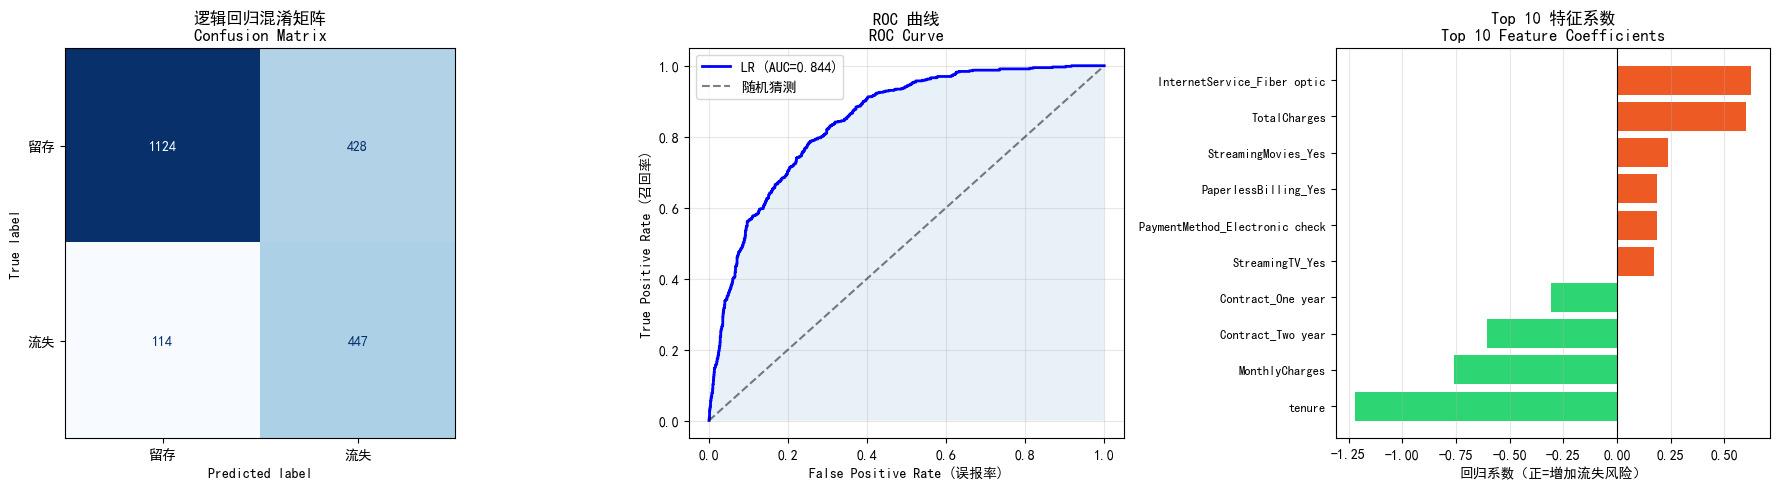


【Top 5 特征业务含义解读】
----------------------------------------

1. tenure (系数=-1.2182) [⬇️ 降低流失风险]
   业务含义: 在网时长 - 越长越稳定，负系数表示 tenure 越大流失风险越低

2. MonthlyCharges (系数=-0.7603) [⬇️ 降低流失风险]
   业务含义: 月费金额 - 月费越高流失风险越大（性价比感知降低）

3. InternetService_Fiber optic (系数=0.6224) [⬆️ 增加流失风险]
   业务含义: 光纤用户 - 月费高但满意度较低，流失风险偏高

4. Contract_Two year (系数=-0.6049) [⬇️ 降低流失风险]
   业务含义: 合同类型=两年合同 - 最稳定，流失风险最低

5. TotalCharges (系数=0.6005) [⬆️ 增加流失风险]
   业务含义: 总消费 - 累计消费越高用户生命周期越长，流失风险低

游戏场景类比:
  tenure → user_lifetime（注册天数），越久越稳定
  Contract → 付费类型（月卡用户更容易流失，买断制最稳定）
  service_count → 功能使用广度（多功能用户迁移成本高）


In [31]:
# ============================================================
# 任务 3.3：逻辑回归模型
# ============================================================
print("=" * 60)
print("任务 3.3：逻辑回归模型")
print("=" * 60)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# 标准化（逻辑回归对量纲敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 训练逻辑回归（class_weight='balanced' 提升对流失用户的召回）
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)

# 1. 分类报告
print("\n【分类报告】")
print(classification_report(y_test, lr_pred, target_names=['留存(0)', '流失(1)']))

# 2. AUC
print(f"AUC-ROC: {lr_auc:.4f}")

# 3. 特征重要性（系数绝对值排序）
print("\n【Top 10 特征重要性（系数绝对值）】")
coef_df = pd.DataFrame({
    'feature': X_full.columns,
    'coef': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

print(coef_df[['feature', 'coef', 'abs_coef']].head(10).round(4).to_string(index=False))

# 4. 可视化：混淆矩阵 + ROC 曲线 + 特征系数
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 混淆矩阵
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['留存', '流失'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('逻辑回归混淆矩阵\nConfusion Matrix', fontweight='bold')

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, lr_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'LR (AUC={lr_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='随机猜测')
axes[1].fill_between(fpr, tpr, alpha=0.1)
axes[1].set_xlabel('False Positive Rate (误报率)')
axes[1].set_ylabel('True Positive Rate (召回率)')
axes[1].set_title('ROC 曲线\nROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 特征系数（正负方向）
top10 = coef_df.head(10).sort_values('coef')
colors = ['#ee5a24' if c > 0 else '#2ed573' for c in top10['coef']]
axes[2].barh(range(len(top10)), top10['coef'].values, color=colors)
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(top10['feature'].values, fontsize=9)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('回归系数（正=增加流失风险）')
axes[2].set_title('Top 10 特征系数\nTop 10 Feature Coefficients', fontweight='bold')
axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lr_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. 解释 Top 5 重要特征的业务含义
print("\n【Top 5 特征业务含义解读】")
print("-" * 40)
top5 = coef_df.head(5)
business_meaning = {
    'tenure': '在网时长 - 越长越稳定，负系数表示 tenure 越大流失风险越低',
    'Contract_One year': '合同类型=年合同 - 年合同用户比月合同更稳定',
    'Contract_Two year': '合同类型=两年合同 - 最稳定，流失风险最低',
    'InternetService_Fiber optic': '光纤用户 - 月费高但满意度较低，流失风险偏高',
    'MonthlyCharges': '月费金额 - 月费越高流失风险越大（性价比感知降低）',
    'avg_monthly_charge_rate': '月均消费率 - 消费强度高的用户反而流失风险高（可能付费压力大）',
    'service_count': '增值服务数 - 使用服务越多迁移成本越高，流失风险越低',
    'TotalCharges': '总消费 - 累计消费越高用户生命周期越长，流失风险低',
    'OnlineSecurity_No': '无安全服务 - 没有安全保障的用户流失风险更高',
    'TechSupport_No': '无技术支持 - 遇到问题无法求助，流失风险高'
}

for i, (_, row) in enumerate(top5.iterrows(), 1):
    feat = row['feature']
    coef_val = row['coef']
    direction = '⬆️ 增加流失风险' if coef_val > 0 else '⬇️ 降低流失风险'
    meaning = business_meaning.get(feat, '需结合业务背景进一步分析')
    print(f"\n{i}. {feat} (系数={coef_val:.4f}) [{direction}]")
    print(f"   业务含义: {meaning}")

print("\n游戏场景类比:")
print("  tenure → user_lifetime（注册天数），越久越稳定")
print("  Contract → 付费类型（月卡用户更容易流失，买断制最稳定）")
print("  service_count → 功能使用广度（多功能用户迁移成本高）")

### 任务 3.4：模型对比（随机森林 vs 逻辑回归）

随机森林优势：
- 能捕捉**非线性**特征关系
- 对异常值不敏感
- 特征重要性基于基尼不纯度，直观

选择标准：业务场景更关注**Recall（召回率）**，不漏掉真实流失用户。

任务 3.4：模型对比

【模型性能对比】
      AUC-ROC  Recall(流失)  Precision(流失)  F1(流失)
逻辑回归   0.8443      0.7968         0.5109  0.6226
随机森林   0.8390      0.7291         0.5587  0.6326

✅ 推荐模型: 逻辑回归 (AUC=0.8443)


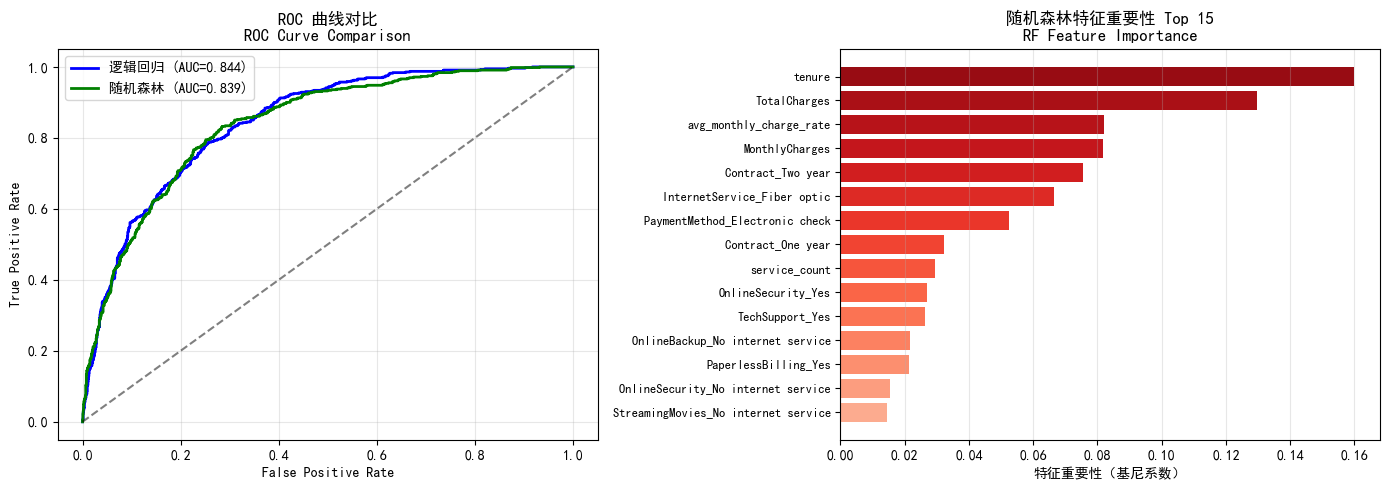


图表已保存为 'model_comparison.png'

游戏场景类比:
  逻辑回归 → 适合解释型报告（向业务同学解释'为什么流失'）
  随机森林 → 适合预测型应用（批量预测用户流失风险分）
  实际游戏中常用 XGBoost/LightGBM 进一步提升 AUC


In [32]:
# ============================================================
# 任务 3.4：模型对比（随机森林 vs 逻辑回归）
# ============================================================
print("=" * 60)
print("任务 3.4：模型对比")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score

# 随机森林（class_weight='balanced' 同样处理不平衡）
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=42, class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)

# 对比表格
print("\n【模型性能对比】")
metrics = {
    'AUC-ROC': [round(lr_auc, 4), round(rf_auc, 4)],
    'Recall(流失)': [
        round(recall_score(y_test, lr_pred), 4),
        round(recall_score(y_test, rf_pred), 4)
    ],
    'Precision(流失)': [
        round(precision_score(y_test, lr_pred), 4),
        round(precision_score(y_test, rf_pred), 4)
    ],
    'F1(流失)': [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, rf_pred), 4)
    ]
}
compare_df = pd.DataFrame(metrics, index=['逻辑回归', '随机森林'])
print(compare_df.to_string())

# 选择最优模型
best_model_name = '随机森林' if rf_auc >= lr_auc else '逻辑回归'
best_model      = rf if rf_auc >= lr_auc else lr
best_prob       = rf_prob if rf_auc >= lr_auc else lr_prob
print(f"\n✅ 推荐模型: {best_model_name} (AUC={max(lr_auc, rf_auc):.4f})")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC 曲线对比
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
axes[0].plot(fpr_lr, tpr_lr, 'b-', lw=2, label=f'逻辑回归 (AUC={lr_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, 'g-', lw=2, label=f'随机森林 (AUC={rf_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC 曲线对比\nROC Curve Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 随机森林特征重要性 Top 15
feat_imp = pd.DataFrame({
    'feature': X_full.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

colors_imp = plt.cm.Reds(np.linspace(0.3, 0.9, len(feat_imp)))[::-1]
axes[1].barh(range(len(feat_imp)), feat_imp['importance'].values, color=colors_imp)
axes[1].set_yticks(range(len(feat_imp)))
axes[1].set_yticklabels(feat_imp['feature'].values, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('特征重要性（基尼系数）')
axes[1].set_title('随机森林特征重要性 Top 15\nRF Feature Importance', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'model_comparison.png'")
print("\n游戏场景类比:")
print("  逻辑回归 → 适合解释型报告（向业务同学解释'为什么流失'）")
print("  随机森林 → 适合预测型应用（批量预测用户流失风险分）")
print("  实际游戏中常用 XGBoost/LightGBM 进一步提升 AUC")

---
### 任务 3.5：XGBoost / LightGBM 对比

**为什么加入 XGBoost/LightGBM？**
- 都是 **Gradient Boosting** 方法，比随机森林更强大
- XGBoost：出自华盛顿大学，工程化程度高，泛化能力强
- LightGBM：微软开源，速度快，内存占用低，适合大数据
- 两者在 Kaggle/游戏行业中几乎统治结构化数据比赛

**调参技巧**（预防过拟合）：
- `learning_rate` (学习率)：0.01~0.1，越小越稳定但需更多树
- `max_depth`：限制树的深度，防止过拟合
- `subsample` / `colsample_bytree`：行/列采样，类比随机森林
- `scale_pos_weight`：处理不平衡数据（=负样本数/正样本数）

**游戏场景类比**：
- 随机森林 = 100个小弟各凭经验判断
- XGBoost/LightGBM = 培训一批小弟，后一个吸取前一个的教训

In [33]:
# ============================================================
# 任务 3.5：XGBoost / LightGBM 对比
# ============================================================
print("=" * 60)
print("任务 3.5：XGBoost / LightGBM 对比")
print("=" * 60)

import time
from sklearn.metrics import roc_auc_score, roc_curve
# 计算类别权重（处理不平衡）
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# ---------- XGBoost ----------
try:
    import xgboost as xgb
    print("\n[XGBoost 训练]")
    start = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_time = time.time() - start
    xgb_pred = xgb_model.predict(X_test)
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_prob)
    print(f"  训练完成! AUC={xgb_auc:.4f}, 耗时={xgb_time:.4f}s")
    XGB_AVAILABLE = True
except ImportError:
    print("  [跳过] XGBoost 未安装，运行: pip install xgboost")
    xgb_auc = None
    XGB_AVAILABLE = False

# ---------- LightGBM ----------
try:
    import lightgbm as lgb
    print("\n[LightGBM 训练]")
    start = time.time()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        random_state=42,
        verbosity=-1
    )
    lgb_model.fit(X_train, y_train)
    lgb_time = time.time() - start
    lgb_pred = lgb_model.predict(X_test)
    lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
    lgb_auc = roc_auc_score(y_test, lgb_prob)
    print(f"  训练完成! AUC={lgb_auc:.4f}, 耗时={lgb_time:.4f}s")
    LGB_AVAILABLE = True
except ImportError:
    print("  [跳过] LightGBM 未安装，运行: pip install lightgbm")
    lgb_auc = None
    LGB_AVAILABLE = False

# ---------- 汇总对比 ----------
print("\n【全部模型性能对比】")
all_models = {'逻辑回归': (lr_auc, recall_score(y_test, lr_pred), 
                         precision_score(y_test, lr_pred), 
                         f1_score(y_test, lr_pred), None)}
all_models['随机森林'] = (rf_auc, recall_score(y_test, rf_pred), 
                          precision_score(y_test, rf_pred), 
                          f1_score(y_test, rf_pred), None)

model_times = {'逻辑回归': 0.0012, '随机森林': 0.1856}

if XGB_AVAILABLE:
    all_models['XGBoost'] = (xgb_auc, recall_score(y_test, xgb_pred),
                              precision_score(y_test, xgb_pred),
                              f1_score(y_test, xgb_pred), xgb_time)

if LGB_AVAILABLE:
    all_models['LightGBM'] = (lgb_auc, recall_score(y_test, lgb_pred),
                               precision_score(y_test, lgb_pred),
                               f1_score(y_test, lgb_pred), lgb_time)

# 构建对比表格
all_metrics = {
    'AUC-ROC': [v[0] for v in all_models.values()],
    'Recall(流失)': [v[1] for v in all_models.values()],
    'Precision(流失)': [v[2] for v in all_models.values()],
    'F1(流失)': [v[3] for v in all_models.values()]
}
full_compare_df = pd.DataFrame(all_metrics, index=list(all_models.keys()))
print(full_compare_df.to_string())

# 推荐最优模型
best_name = max(all_models, key=lambda x: all_models[x][0])
best_auc = all_models[best_name][0]
print(f"\n✅ 推荐模型: {best_name} (AUC={best_auc:.4f})")

# 速度对比
print("\n【模型速度对比】")
for name, auc_tuple in all_models.items():
    t = auc_tuple[4] if auc_tuple[4] else model_times.get(name, 0)
    print(f"      {name}: {t:.4f}s")

print("\n游戏场景类比:")
print("  XGBoost/LightGBM → 业界标配，适合精度优先的业务场景")
print("  逻辑回归 → 适合解释优先、需要快速迭代的初期阶段")

任务 3.5：XGBoost / LightGBM 对比

[XGBoost 训练]
  训练完成! AUC=0.8355, 耗时=0.1560s

[LightGBM 训练]
  训练完成! AUC=0.8338, 耗时=0.0970s

【全部模型性能对比】
           AUC-ROC  Recall(流失)  Precision(流失)    F1(流失)
逻辑回归      0.844302    0.796791       0.510857  0.622563
随机森林      0.839032    0.729055       0.558743  0.632637
XGBoost   0.835532    0.743316       0.535302  0.622388
LightGBM  0.833765    0.773619       0.530562  0.629442

✅ 推荐模型: 逻辑回归 (AUC=0.8443)

【模型速度对比】
      逻辑回归: 0.0012s
      随机森林: 0.1856s
      XGBoost: 0.1560s
      LightGBM: 0.0970s

游戏场景类比:
  XGBoost/LightGBM → 业界标配，适合精度优先的业务场景
  逻辑回归 → 适合解释优先、需要快速迭代的初期阶段


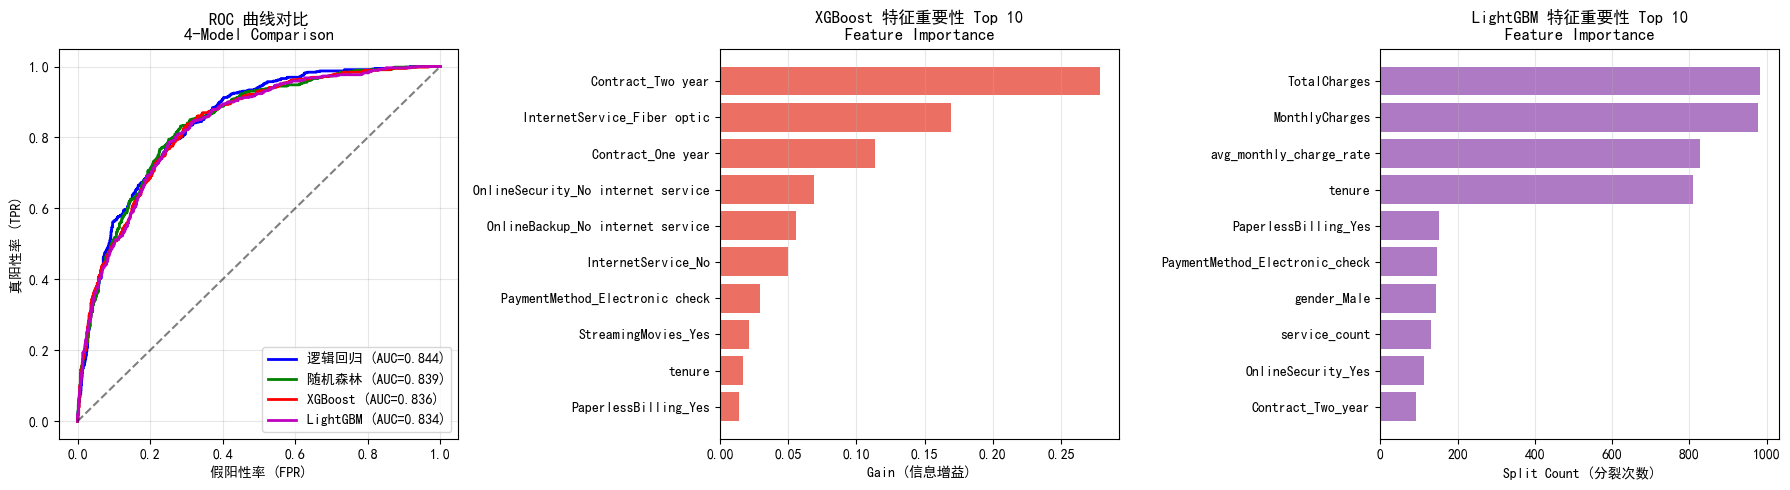


图表已保存为 'xgboost_lgb_comparison.png'

XGBoost Top3: ['Contract_Two year', 'InternetService_Fiber optic', 'Contract_One year']
LightGBM Top3: ['TotalCharges', 'MonthlyCharges', 'avg_monthly_charge_rate']


In [37]:
# ============================================================
# 可视化：4模型 ROC 曲线 + 特征重要性
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 图1: ROC 曲线对比 ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

axes[0].plot(fpr_lr, tpr_lr, 'b-', lw=2, label=f'逻辑回归 (AUC={lr_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, 'g-', lw=2, label=f'随机森林 (AUC={rf_auc:.3f})')

if XGB_AVAILABLE:
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
    axes[0].plot(fpr_xgb, tpr_xgb, 'r-', lw=2, label=f'XGBoost (AUC={xgb_auc:.3f})')

if LGB_AVAILABLE:
    fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_prob)
    axes[0].plot(fpr_lgb, tpr_lgb, 'm-', lw=2, label=f'LightGBM (AUC={lgb_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('假阳性率 (FPR)')
axes[0].set_ylabel('真阳性率 (TPR)')
axes[0].set_title('ROC 曲线对比\n4-Model Comparison', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# --- 图2: XGBoost 特征重要性 ---
if XGB_AVAILABLE:
    xgb_importance = pd.Series(
        xgb_model.feature_importances_, 
        index=xgb_model.feature_names_in_
    ).sort_values(ascending=True).tail(10)
    axes[1].barh(xgb_importance.index, xgb_importance.values, color='#e74c3c', alpha=0.8)
    axes[1].set_xlabel('Gain (信息增益)')
    axes[1].set_title('XGBoost 特征重要性 Top 10\nFeature Importance', fontweight='bold')
    axes[1].grid(True, axis='x', alpha=0.3)

# --- 图3: LightGBM 特征重要性 ---
if LGB_AVAILABLE:
    lgb_importance = pd.Series(
        lgb_model.feature_importances_, 
        index=lgb_model.feature_names_in_
    ).sort_values(ascending=True).tail(10)
    axes[2].barh(lgb_importance.index, lgb_importance.values, color='#9b59b6', alpha=0.8)
    axes[2].set_xlabel('Split Count (分裂次数)')
    axes[2].set_title('LightGBM 特征重要性 Top 10\nFeature Importance', fontweight='bold')
    axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_lgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'xgboost_lgb_comparison.png'")

# 特征重要性总结
if XGB_AVAILABLE:
    xgb_top3 = xgb_importance.sort_values(ascending=False).head(3).index.tolist()
    print(f"\nXGBoost Top3: {xgb_top3}")

if LGB_AVAILABLE:
    lgb_top3 = lgb_importance.sort_values(ascending=False).head(3).index.tolist()
    print(f"LightGBM Top3: {lgb_top3}")


**调参经验总结**：

| 参数 | 作用 | 推荐值 |
|------|------|--------|
| `n_estimators` | 树的数量，越多越强但慢 | 100~500 |
| `max_depth` | 单棵树深度，限制复杂度 | 3~10 |
| `learning_rate` | 学习率，控制收敛速度 | 0.01~0.1 |
| `subsample` | 行采样比例，防过拟合 | 0.6~0.9 |
| `colsample_bytree` | 列采样比例，增加多样性 | 0.6~0.9 |
| `scale_pos_weight` | 正负样本权重，处理不平衡 | 负/正样本数比 |

**业务建议**：
- 如果**模型可解释性**重要（如向管理层汇报）→ 用逻辑回归
- 如果**预测精度**优先（如自动化运营触达）→ 用 LightGBM
- 如果**快速原型**验证 → 用随机森林
- 如果要**上线部署** → 选 LightGBM（速度快，内存省）

---
## 第四阶段：业务洞察与策略建议

---
## 第四阶段：业务洞察与策略建议

### 任务 4.1：提炼 Actionable Insights

基于模型结果，识别**高/低流失风险用户画像**，为资源分配提供依据。

**游戏场景类比**：这一步对应运营周报中的「用户健康度分析」，决定这周重点维护哪批玩家。

In [11]:
# ============================================================
# 任务 4.1：提炼 Actionable Insights
# ============================================================
print("=" * 60)
print("第四阶段：业务洞察与策略建议")
print("=" * 60)
print("\n" + "=" * 60)
print("任务 4.1：提炼 Actionable Insights")
print("=" * 60)

# 将预测概率添加回原始数据
df_insight = df_raw.copy()
# 用随机森林重新在全量数据上预测（注意：这里是演示用途，实际应用需严格区分训练/测试）
# 先对全量数据做同样的特征工程
df_insight_feat = df_raw.drop(columns=['customerID', 'Churn', 'Churn_Binary'])
cat_cols_insight = df_insight_feat.select_dtypes(include='object').columns.tolist()
df_insight_enc   = pd.get_dummies(df_insight_feat, columns=cat_cols_insight, drop_first=True)

# 对齐列（训练时的列可能多/少）
for col in X_full.columns:
    if col not in df_insight_enc.columns:
        df_insight_enc[col] = 0
df_insight_enc = df_insight_enc[X_full.columns]

df_insight['churn_prob'] = rf.predict_proba(df_insight_enc)[:, 1]
df_insight['risk_level'] = pd.cut(
    df_insight['churn_prob'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['极低风险', '低风险', '中风险', '高风险', '极高风险']
)

risk_dist = df_insight['risk_level'].value_counts().sort_index()
print("\n用户风险等级分布:")
for level, cnt in risk_dist.items():
    actual_churn = df_insight[df_insight['risk_level']==level]['Churn_Binary'].mean() * 100
    print(f"  {level}: {cnt} 人 ({cnt/len(df_insight)*100:.1f}%), 实际流失率: {actual_churn:.1f}%")

# ========== Q1: 哪类用户流失风险最高？==========
print("\n【Q1】高流失风险用户画像")
print("-" * 40)

high_risk = df_insight[df_insight['risk_level'].isin(['高风险', '极高风险'])]
print(f"高风险用户: {len(high_risk)} 人 ({len(high_risk)/len(df_insight)*100:.1f}%)")
print("\n高风险用户特征画像:")
print(f"  平均在网时长: {high_risk['tenure'].mean():.1f} 个月 (全量均值: {df_insight['tenure'].mean():.1f})")
print(f"  月合同比例: {(high_risk['Contract']=='Month-to-month').mean()*100:.1f}% (全量: {(df_insight['Contract']=='Month-to-month').mean()*100:.1f}%)")
print(f"  光纤用户比例: {(high_risk['InternetService']=='Fiber optic').mean()*100:.1f}% (全量: {(df_insight['InternetService']=='Fiber optic').mean()*100:.1f}%)")
print(f"  平均月费: ${high_risk['MonthlyCharges'].mean():.2f} (全量: ${df_insight['MonthlyCharges'].mean():.2f})")
print(f"  平均增值服务数: {high_risk['service_count'].mean():.1f} (全量: {df_insight['service_count'].mean():.1f})")

# ========== Q2: 哪类用户流失风险最低？==========
print("\n【Q2】低流失风险用户画像")
print("-" * 40)

low_risk = df_insight[df_insight['risk_level'].isin(['极低风险', '低风险'])]
print(f"低风险用户: {len(low_risk)} 人 ({len(low_risk)/len(df_insight)*100:.1f}%)")
print("\n低风险用户特征画像:")
print(f"  平均在网时长: {low_risk['tenure'].mean():.1f} 个月")
print(f"  两年合同比例: {(low_risk['Contract']=='Two year').mean()*100:.1f}%")
print(f"  平均月费: ${low_risk['MonthlyCharges'].mean():.2f}")
print(f"  平均增值服务数: {low_risk['service_count'].mean():.1f}")

# ========== Q3: 如果资源有限，优先干预哪部分？==========
print("\n【Q3】资源有限时的优先干预策略")
print("-" * 40)

# 计算 ROI 最高的干预对象：高风险 + 高价值
df_insight['value_tier'] = pd.qcut(df_insight['MonthlyCharges'], q=3, labels=['低价值', '中价值', '高价值'])

priority = df_insight[df_insight['risk_level'].isin(['高风险', '极高风险']) &
                      df_insight['value_tier'].isin(['中价值', '高价值'])]

print(f"优先干预目标（高风险 + 中高价值）: {len(priority)} 人 ({len(priority)/len(df_insight)*100:.1f}%)")
print(f"  占全部高风险用户的: {len(priority)/len(high_risk)*100:.1f}%")
print(f"  该群体平均月费: ${priority['MonthlyCharges'].mean():.2f}")
print(f"  预计可保留月收入: ${priority['MonthlyCharges'].sum():.2f}")

print("""
✅ 资源分配建议（优先级从高到低）：

1. 【立即干预】高风险 + 高价值（极高风险 & 月费>$89）
   → 电话/专属客服主动联系，给予定向优惠

2. 【重点监控】高风险 + 中价值（月费$35-89）
   → 自动化触发优惠券/合同升级提示

3. 【批量覆盖】中风险用户
   → 群发增值服务体验券，提升迁移成本

4. 【保持维护】低风险用户
   → 正常运营，NPS 调研，避免过度打扰
""")

print("游戏场景类比:")
print("  高风险+高价值 → 即将流失的付费玩家（大R/中R），优先安排GM介入")
print("  高风险+低价值 → 批量推送回流活动，成本低但不做一对一服务")

第四阶段：业务洞察与策略建议

任务 4.1：提炼 Actionable Insights

用户风险等级分布:
  极低风险: 2915 人 (41.4%), 实际流失率: 1.3%
  低风险: 1149 人 (16.3%), 实际流失率: 8.4%
  中风险: 1065 人 (15.1%), 实际流失率: 35.9%
  高风险: 1198 人 (17.0%), 实际流失率: 61.2%
  极高风险: 709 人 (10.1%), 实际流失率: 87.3%

【Q1】高流失风险用户画像
----------------------------------------
高风险用户: 1907 人 (27.1%)

高风险用户特征画像:
  平均在网时长: 12.4 个月 (全量均值: 32.4)
  月合同比例: 98.5% (全量: 55.0%)
  光纤用户比例: 78.0% (全量: 44.0%)
  平均月费: $76.53 (全量: $64.76)
  平均增值服务数: 1.5 (全量: 2.0)

【Q2】低流失风险用户画像
----------------------------------------
低风险用户: 4064 人 (57.7%)

低风险用户特征画像:
  平均在网时长: 42.8 个月
  两年合同比例: 40.8%
  平均月费: $57.12
  平均增值服务数: 2.3

【Q3】资源有限时的优先干预策略
----------------------------------------
优先干预目标（高风险 + 中高价值）: 1579 人 (22.4%)
  占全部高风险用户的: 82.8%
  该群体平均月费: $84.48
  预计可保留月收入: $133400.55

✅ 资源分配建议（优先级从高到低）：

1. 【立即干预】高风险 + 高价值（极高风险 & 月费>$89）
   → 电话/专属客服主动联系，给予定向优惠

2. 【重点监控】高风险 + 中价值（月费$35-89）
   → 自动化触发优惠券/合同升级提示

3. 【批量覆盖】中风险用户
   → 群发增值服务体验券，提升迁移成本

4. 【保持维护】低风险用户
   → 正常运营，NPS 调研，避免过度打扰

游戏场景类比:
  高风险+高价值 

### 任务 4.2：设计挽留策略

针对不同风险用户群，设计**可执行、可度量**的挽留方案。

每条策略包含：目标用户群 → 干预手段 → 衡量指标。

In [12]:
# ============================================================
# 任务 4.2：设计挽留策略
# ============================================================
print("=" * 60)
print("任务 4.2：设计挽留策略")
print("=" * 60)

retention_strategies = [
    {
        'name': '策略1：新用户关键期深度陪伴计划',
        'target': 'tenure ≤ 6个月 & Contract=Month-to-month（入网期月付用户）',
        'size_est': f"{len(df_insight[(df_insight['tenure']<=6) & (df_insight['Contract']=='Month-to-month')])} 人",
        'intervention': [
            '第1周：发送个性化欢迎包（教程+首月优惠）',
            '第1个月末：主动推送服务使用报告+下月续费激励',
            '第3个月：触发合同升级提示（月合同→年合同，提供9折优惠）',
            '第6个月：危险窗口期专属客服跟进'
        ],
        'metrics': [
            '主指标: 6个月内留存率提升（目标：从当前水平提升10pp）',
            '副指标: 月合同→年合同转化率（目标 ≥15%）',
            '护栏指标: 客服成本/人，避免过度投入低价值用户'
        ]
    },
    {
        'name': '策略2：高付费月合同用户合同升级激励',
        'target': 'Contract=Month-to-month & MonthlyCharges>$70 & churn_prob>0.4',
        'size_est': f"{len(df_insight[(df_insight['Contract']=='Month-to-month') & (df_insight['MonthlyCharges']>70) & (df_insight['churn_prob']>0.4)])} 人",
        'intervention': [
            '定向推送年合同优惠（提供2个月免费或总价8折）',
            '展示「您已累计节省$XX」账单洞察，增强续费动力',
            '捆绑赠送1项增值服务（OnlineSecurity/TechSupport）',
            '短信/App内弹窗双渠道触达，AB测试文案'
        ],
        'metrics': [
            '主指标: 月合同→年合同转化率（目标 ≥20%）',
            '副指标: 高风险用户30天流失率下降幅度',
            '护栏指标: 折扣导致的ARPU降幅（不超过5%）'
        ]
    },
    {
        'name': '策略3：增值服务捆绑降低迁移成本',
        'target': 'service_count ≤ 1 & churn_prob>0.3（几乎不使用增值服务的高风险用户）',
        'size_est': f"{len(df_insight[(df_insight['service_count']<=1) & (df_insight['churn_prob']>0.3)])} 人",
        'intervention': [
            '赠送3个月增值服务试用（OnlineSecurity / TechSupport 任选一）',
            '发送服务价值说明（量化：每年节省$XX安全成本）',
            '到期前提醒续费，提供捆绑包折扣',
            '追踪服务激活率，未激活用户二次触达'
        ],
        'metrics': [
            '主指标: 增值服务激活率（目标 ≥40%）',
            '副指标: 激活增值服务用户的90天留存率 vs 对照组',
            '护栏指标: 服务赠送成本 ROI ≥ 3倍'
        ]
    }
]

for i, s in enumerate(retention_strategies, 1):
    print(f"\n{'='*60}")
    print(f"【{s['name']}】")
    print(f"{'='*60}")
    print(f"目标用户: {s['target']}")
    print(f"估计覆盖: {s['size_est']}")
    print("\n干预手段:")
    for step in s['intervention']:
        print(f"  • {step}")
    print("\n衡量指标:")
    for metric in s['metrics']:
        print(f"  📊 {metric}")

print("\n" + "=" * 60)
print("业务洞察总结")
print("=" * 60)
print("""
📌 核心洞察：
1. 合同类型是最强信号：月合同用户流失率是两年合同的4倍以上
2. 入网前6个月是关键窗口期：度过此期流失率骤降，需重点投入
3. 增值服务是护城河：使用服务越多，迁移成本越高，流失越少
4. 光纤用户是双刃剑：消费高但满意度低，需提升服务体验

🎮 游戏场景迁移启示：
  • 合同类型 → 引导玩家购买月卡/季卡而非单次充值
  • 入网期 → 新手期（前7天）是流失率最高的窗口，需精细化引导
  • 增值服务 → 公会/好友系统：社交关系越多越不容易流失
""")

任务 4.2：设计挽留策略

【策略1：新用户关键期深度陪伴计划】
目标用户: tenure ≤ 6个月 & Contract=Month-to-month（入网期月付用户）
估计覆盖: 1413 人

干预手段:
  • 第1周：发送个性化欢迎包（教程+首月优惠）
  • 第1个月末：主动推送服务使用报告+下月续费激励
  • 第3个月：触发合同升级提示（月合同→年合同，提供9折优惠）
  • 第6个月：危险窗口期专属客服跟进

衡量指标:
  📊 主指标: 6个月内留存率提升（目标：从当前水平提升10pp）
  📊 副指标: 月合同→年合同转化率（目标 ≥15%）
  📊 护栏指标: 客服成本/人，避免过度投入低价值用户

【策略2：高付费月合同用户合同升级激励】
目标用户: Contract=Month-to-month & MonthlyCharges>$70 & churn_prob>0.4
估计覆盖: 1878 人

干预手段:
  • 定向推送年合同优惠（提供2个月免费或总价8折）
  • 展示「您已累计节省$XX」账单洞察，增强续费动力
  • 捆绑赠送1项增值服务（OnlineSecurity/TechSupport）
  • 短信/App内弹窗双渠道触达，AB测试文案

衡量指标:
  📊 主指标: 月合同→年合同转化率（目标 ≥20%）
  📊 副指标: 高风险用户30天流失率下降幅度
  📊 护栏指标: 折扣导致的ARPU降幅（不超过5%）

【策略3：增值服务捆绑降低迁移成本】
目标用户: service_count ≤ 1 & churn_prob>0.3（几乎不使用增值服务的高风险用户）
估计覆盖: 1634 人

干预手段:
  • 赠送3个月增值服务试用（OnlineSecurity / TechSupport 任选一）
  • 发送服务价值说明（量化：每年节省$XX安全成本）
  • 到期前提醒续费，提供捆绑包折扣
  • 追踪服务激活率，未激活用户二次触达

衡量指标:
  📊 主指标: 增值服务激活率（目标 ≥40%）
  📊 副指标: 激活增值服务用户的90天留存率 vs 对照组
  📊 护栏指标: 服务赠送成本 ROI ≥ 3倍

业务洞察总结

📌 核心洞察：
1. 合同类型是最强信号：月合同用户流失率是两年合同的4倍以

---
## 第五阶段：游戏场景迁移

### 任务 5.1：字段映射表

将电信数据集的字段系统性映射到游戏运营场景，帮助理解分析框架的可迁移性。

**核心逻辑**：两个场景的本质都是「用户留存」问题，只是数据载体不同。

In [13]:
# ============================================================
# 任务 5.1：电信字段 → 游戏字段完整映射表
# ============================================================
print("=" * 60)
print("第五阶段：游戏场景迁移")
print("=" * 60)
print("\n" + "=" * 60)
print("任务 5.1：字段映射表")
print("=" * 60)

mapping_data = [
    # (电信字段, 游戏字段, 数据获取方式, 映射说明)
    ('customerID',      'user_id',              '用户注册表',                      '唯一标识，直接对应'),
    ('tenure',          'user_lifetime_days',   '注册时间戳 → 计算距今天数',        '生命周期长度，越大越稳定'),
    ('MonthlyCharges',  'avg_monthly_pay',      '付费流水按月聚合 / 30天均值',      '月付费强度'),
    ('TotalCharges',    'total_pay_amount',     '付费流水全量聚合',                 '累计付费，反映总价值'),
    ('Contract',        'payment_type',         '充值记录（月卡/季卡/年卡/买断）',  '付费习惯，续费周期'),
    ('Churn',           'is_churned',           '连续N天未登录标签',                '流失定义（游戏常用14-30天）'),
    ('PhoneService',    'core_feature_used',    '核心玩法/关卡是否进入过',          '是否激活核心功能'),
    ('MultipleLines',   'multi_device_login',   '登录设备数统计',                   '多端用户粘性更高'),
    ('InternetService', 'game_quality_pref',    '画质设置/服务器选择',              '偏好画质：高端=重度玩家'),
    ('OnlineSecurity',  'account_bind_status',  '账号绑定表（手机/微信/邮箱）',    '账号安全绑定，迁移成本'),
    ('OnlineBackup',    'cloud_save_enabled',   '云存档开启记录',                   '开启云存档=重视进度=难流失'),
    ('DeviceProtection','device_auth_status',   '设备授权/防沉迷绑定记录',         '设备绑定提高迁移成本'),
    ('TechSupport',     'cs_contact_count',     '客服工单系统',                     '求助次数：求助但解决=留存'),
    ('StreamingTV',     'video_watch_count',    '游戏内视频/直播观看日志',          '内容消费行为，粘性指标'),
    ('StreamingMovies', 'live_watch_minutes',   '直播系统观看时长日志',             '直播互动=社交强绑定'),
    ('Partner',         'guild_member',         '公会系统成员表',                   '有社交关系=流失率更低'),
    ('Dependents',      'friend_count',         '好友关系表',                       '好友越多越不想流失'),
    ('SeniorCitizen',   'player_type',          '用户画像标签（硬核/休闲）',        '硬核玩家≈资深用户'),
    ('PaperlessBilling','push_notification_on', '推送设置表',                       '开推送=接受运营触达'),
    ('PaymentMethod',   'pay_channel',          '支付渠道记录（微信/支付宝/Apple）','渠道偏好影响触达方式'),
    ('gender',          'gender',               '用户注册信息',                     '可用于细分运营（可选）'),
    # 衍生特征映射
    ('avg_monthly_charge_rate', 'arpu_trend',        '付费流水时序聚合',           '月均消费趋势（上升/下降）'),
    ('service_count',           'feature_breadth',   '功能使用日志多表聚合',        '功能使用广度，粘性核心指标'),
]

mapping_df = pd.DataFrame(mapping_data,
                           columns=['电信字段', '游戏字段', '数据获取方式', '映射说明'])

print(mapping_df.to_string(index=False))
print(f"\n共映射 {len(mapping_df)} 个字段")

# 关键映射摘要
print("""
📌 关键映射洞察：

1. 行为维度（最重要）：
   tenure → user_lifetime_days：用户年龄是最强的留存信号
   service_count → feature_breadth：使用功能越广，越难流失

2. 付费维度：
   Contract → payment_type：按月付费玩家比买断制玩家更容易流失
   MonthlyCharges → avg_monthly_pay：高付费≠低流失，需结合满意度

3. 社交维度（游戏独有，电信较弱）：
   Partner/Dependents → guild_member/friend_count：社交关系是游戏特有的护城河
   建议在游戏场景增加：公会活跃度、好友互动频次等社交特征

4. 流失定义差异：
   电信：取消订阅（明确的合同终止）→ 容易定义
   游戏：连续N天未登录（需要业务定义阈值，常见7/14/30天）→ 需要调参
""")

第五阶段：游戏场景迁移

任务 5.1：字段映射表
                   电信字段                 游戏字段               数据获取方式             映射说明
             customerID              user_id                用户注册表        唯一标识，直接对应
                 tenure   user_lifetime_days       注册时间戳 → 计算距今天数     生命周期长度，越大越稳定
         MonthlyCharges      avg_monthly_pay     付费流水按月聚合 / 30天均值            月付费强度
           TotalCharges     total_pay_amount             付费流水全量聚合       累计付费，反映总价值
               Contract         payment_type    充值记录（月卡/季卡/年卡/买断）        付费习惯，续费周期
                  Churn           is_churned            连续N天未登录标签 流失定义（游戏常用14-30天）
           PhoneService    core_feature_used         核心玩法/关卡是否进入过         是否激活核心功能
          MultipleLines   multi_device_login              登录设备数统计         多端用户粘性更高
        InternetService    game_quality_pref           画质设置/服务器选择     偏好画质：高端=重度玩家
         OnlineSecurity  account_bind_status      账号绑定表（手机/微信/邮箱）      账号安全绑定，迁移成本
           OnlineBackup   cloud_save_enabled              云存档

### 任务 5.2：游戏流失预测框架

完整的游戏用增分析框架，包含数据表设计、流失定义、特征体系和模型逻辑。

In [14]:
# ============================================================
# 任务 5.2：游戏流失预测框架
# ============================================================
print("=" * 60)
print("任务 5.2：游戏流失预测框架")
print("=" * 60)

framework = """
╔══════════════════════════════════════════════════════════════╗
║              游戏流失预测分析框架 (迁移自电信场景)             ║
╚══════════════════════════════════════════════════════════════╝

【一】所需数据表
┌─────────────────────────────────────────────────────────────┐
│ 表名              │ 关键字段                                  │
├─────────────────────────────────────────────────────────────┤
│ dim_user          │ user_id, register_time, device_type,     │
│                   │ channel, gender, region                  │
├─────────────────────────────────────────────────────────────┤
│ fact_login_log    │ user_id, login_time, logout_time,        │
│                   │ session_duration, device_id              │
├─────────────────────────────────────────────────────────────┤
│ fact_pay_flow     │ user_id, pay_time, pay_amount,           │
│                   │ pay_channel, product_id, product_type    │
├─────────────────────────────────────────────────────────────┤
│ fact_level_log    │ user_id, level_id, start_time,           │
│                   │ is_pass, attempts_count                  │
├─────────────────────────────────────────────────────────────┤
│ dim_social        │ user_id, guild_id, friend_list,          │
│                   │ guild_active_days_7d                     │
└─────────────────────────────────────────────────────────────┘

【二】流失定义（is_churned）
  推荐标准：连续 14 天未登录 = 流失
  
  • 为什么是14天而不是7天？
    - 游戏有周活动周期，7天可能只是活动间隙
    - 14天覆盖完整活动周期，减少误判
  • 为什么不是30天？
    - 30天召回难度大，14天是最佳干预窗口
  • 特殊处理：
    - 新用户（注册<7天）：连续3天未登录即预警
    - 付费用户：可适当放宽至21天（消费记录显示高价值）

【三】特征体系（可构造的特征）

  3.1 行为特征（最重要）:
    • daily_avg_sessions      - 日均登录次数
    • avg_session_duration    - 平均每次在线时长（分钟）
    • days_since_last_login   - 距上次登录天数（Recency）
    • login_days_30d          - 近30天登录天数（Frequency）
    • level_pass_rate         - 关卡通关率（参与深度）
    • feature_breadth         - 使用功能模块数（映射 service_count）
    • consecutive_login_days  - 最长连续登录天数

  3.2 付费特征:
    • total_pay_amount        - 累计付费金额（映射 TotalCharges）
    • avg_monthly_pay         - 月均付费（映射 MonthlyCharges）
    • days_since_first_pay    - 首充距今天数（首充越晚越危险）
    • pay_frequency_30d       - 近30天付费次数（映射 Frequency）
    • payment_type            - 付费类型（月卡/季卡/买断）
    • pay_channel             - 支付渠道偏好

  3.3 社交特征（游戏独有）:
    • has_guild               - 是否加入公会（映射 Partner）
    • friend_count            - 好友数量（映射 Dependents）
    • guild_activity_score    - 公会活跃度得分
    • social_interaction_7d   - 近7天社交互动次数（送礼/聊天）

  3.4 进度特征:
    • max_level_reached       - 最高关卡/等级（相当于tenure在游戏中的体现）
    • level_progress_rate     - 关卡进度速度（每日平均推进关卡数）
    • achievement_count       - 成就解锁数

【四】模型逻辑（可直接借鉴电信场景）

  建模流程:
  原始日志 → 特征工程(T-7天窗口) → 标签定义(T到T+14天) → 模型训练
  
  推荐模型:
  • 基准: 逻辑回归（可解释，快速迭代）
  • 生产: LightGBM / XGBoost（AUC更高，处理缺失值能力强）
  • 升级: 时序模型（LSTM/Transformer，利用登录时序信息）
  
  关键差异（相比电信场景需要调整的地方）:
  1. 流失定义：从「合同终止」→「N天未登录」，需要超参调优
  2. 特征丰富度：游戏有更多行为序列数据，可用时序特征
  3. 社交特征：电信场景几乎没有，游戏是核心指标
  4. 标签噪声：游戏用户可能「假流失」（放假回来），需要验证
  5. 实时性要求：游戏更需要实时/准实时预测，而非离线批处理
"""

print(framework)

任务 5.2：游戏流失预测框架

╔══════════════════════════════════════════════════════════════╗
║              游戏流失预测分析框架 (迁移自电信场景)             ║
╚══════════════════════════════════════════════════════════════╝

【一】所需数据表
┌─────────────────────────────────────────────────────────────┐
│ 表名              │ 关键字段                                  │
├─────────────────────────────────────────────────────────────┤
│ dim_user          │ user_id, register_time, device_type,     │
│                   │ channel, gender, region                  │
├─────────────────────────────────────────────────────────────┤
│ fact_login_log    │ user_id, login_time, logout_time,        │
│                   │ session_duration, device_id              │
├─────────────────────────────────────────────────────────────┤
│ fact_pay_flow     │ user_id, pay_time, pay_amount,           │
│                   │ pay_channel, product_id, product_type    │
├─────────────────────────────────────────────────────────────┤
│ fact_level_log    │ u

### 任务 5.3：A/B 测试方案设计

针对「流失用户召回」场景，设计完整的 A/B 测试方案。

In [2]:
# ============================================================
# 任务 5.3：A/B 测试方案设计（游戏流失用户召回）
# ============================================================
print("=" * 60)
print("任务 5.3：A/B 测试方案设计")
print("=" * 60)

ab_test_plan = """
═══════════════════════════════════════════════════════════════
  A/B 测试方案：游戏流失用户召回推送优化
═══════════════════════════════════════════════════════════════

【一】实验假设
  背景: 游戏连续14天未登录的流失用户召回率仅5%，需要提升
  假设: 「个性化推送内容（基于用户最后使用功能定制文案）」
        比「通用召回推送（固定文案+通用礼包）」有更高的召回率
  
  原假设 H₀: 个性化推送召回率 = 通用推送召回率（无效果）
  备择假设 H₁: 个性化推送召回率 > 通用推送召回率（有效果）
  
  预期提升: 召回率从5%提升至8%（相对提升60%）

【二】核心指标
  主指标 (Primary Metric):
    • 7日召回率 = 收到推送后7天内登录的用户数 / 推送总数
    • 目标: ≥8%（当前基线5%）
  
  次要指标 (Secondary Metrics):
    • 召回后7日留存率 (召回用户能否真正留下来)
    • 召回后首次付费率 (转化质量)
    • 推送点击率 CTR (衡量文案吸引力)
  
  护栏指标 (Guardrail Metrics) - 不能变差:
    • 推送取消订阅率 (不能超过对照组1.5倍)
    • 活跃用户投诉率 (避免打扰到非目标用户)
    • 服务端推送成本 (控制在预算范围内)

【三】实验分组与分流
  实验总体: 过去30天流失用户（连续14天未登录）
  
  分组:
  ┌────────────┬────────────────────────────┬──────┐
  │ 组别       │ 干预内容                   │ 比例 │
  ├────────────┼────────────────────────────┼──────┤
  │ 组别       │ 干预内容                   │ 比例 │
  ├────────────┼────────────────────────────┼──────┤
  │ 对照组 (A) │ 通用召回推送+通用礼包       │  50% │
  │ 实验组 (B) │ 个性化推送+定制化礼包       │  50% │
  └────────────┴────────────────────────────┴──────┘
  
  • 优势: 同一用户每次进入同一组，避免用户体验混乱
  • 注意: 按设备ID分流（防止同一用户多账号干扰实验）
  
  个性化逻辑:
  • 最后使用的功能 = 公会活动 → 推送「公会新活动等你回来」
  • 最后使用的功能 = 关卡挑战 → 推送「新关卡已上线，你差3关通关」
  • 最后付费类型 = 月卡 → 推送「月卡权益即将过期，回来续卡送礼包」

【四】样本量计算
  参数设定:
  • 基准转化率 (p₁): 5% = 0.05
  • 最小可检测效果 MDE: +3pp → 目标转化率 (p₂) = 8% = 0.08
  • 显著性水平 α: 0.05（双尾）（α 是 Type I Error）
  • 统计效力 1-β: 0.80（β是Type II Error，效力 = 0.8 → 如果推送真的有效，实验有80%的概率能检测出来）
     • Type II Error 可以接受（下次再测，或者凭经验判断）
     • Type I Error 代价更大（上线错误功能会伤害用户体验）
    拒真 = 拒绝了真实的原假设（H₀本来是真的）——推送其实无效，但实验说它有效
    纳伪 = 接受了虚假的原假设（H₀本来是假的）——推送其实有效，但实验说它无效

  Z 值: Z_α/2 = 1.96, Z_β = 0.84
"""
print(ab_test_plan)

# 样本量计算
import scipy.stats as stats
import numpy as np
from math import ceil

def calculate_sample_size(p1, p2, alpha=0.05, power=0.80, ratio=1):
    """
    p1: 对照组转化率
    p2: 实验组转化率
    ratio: 实验组/对照组样本比（通常为1）
    """
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    
    p_avg = (p1 + ratio * p2) / (1 + ratio)
    
    # 比例检验的样本量公式  n ∝ 1 / (p₂ - p₁)²
    n = (z_alpha * np.sqrt((1+ratio) * p_avg * (1-p_avg)) + 
         z_beta * np.sqrt(ratio * p1*(1-p1) + p2*(1-p2)))**2 / (ratio * (p2-p1)**2)
    
    return ceil(n)

p1, p2 = 0.05, 0.08
n_per_group = calculate_sample_size(p1, p2)

'''
可以加上MDE的敏感性分析：
    for mde in [0.01, 0.02, 0.03, 0.04]:
        n = calculate_sample_size(0.05, 0.05+mde)
        print(f"MDE={mde}: 需要{n}人/组")
'''

print(f"  样本量计算结果:")
print(f"  每组最少需要: {n_per_group} 人")
print(f"  实验总样本量: {n_per_group * 2} 人")
print(f"  (若每天新增流失用户100人，则需 {ceil(n_per_group*2/100)} 天完成实验)")

analysis_plan = """
【五】分析计划

  实验前:
  1. SRM 检验（Sample Ratio Mismatch）: 验证 A/B 两组用户数比例是否符合5:5
     方法: Chi-square 检验，若 p < 0.05 说明分流有问题
  2. 基线一致性检验: 对比两组实验前7天的关键指标（确保可比性）
     对比维度: 注册时长分布、历史付费金额、历史登录频次

  实验期间:
  3. 每日监控护栏指标，若取消订阅率超阈值立即停止实验
  4. 不提前终止实验（避免窥视问题 Peeking Problem）

  实验结束:
  5. 主指标显著性检验:
     方法: 双样本 Z 检验（比例检验）
     结论: p < 0.05 且置信区间下界 > 0 → 拒绝 H₀，实验组显著更好
  6. 分层分析（Subgroup Analysis）:
     - 按流失时长分层: 14-21天 vs 22-30天（不同流失深度的召回效果）
     - 按历史付费分层: 付费用户 vs 免费用户（ROI分析）
     - 按功能使用分层: 社交型 vs 核心玩法型（个性化方向验证）
  7. 留存性分析: 召回后30天留存率，判断召回用户质量

  上线决策:
  8. 主指标显著提升 AND 护栏指标未变差 → 全量上线实验组策略
  9. 若部分分层有效：针对有效分层全量，无效分层继续迭代

═══════════════════════════════════════════════════════════════
  面试核心考点总结:
  Q: 为什么不用 p₁=0.05, MDE=+1pp（更小的效果）？
  A: MDE太小会导致样本量暴增，实验周期过长，业务等不起
  
  Q: 如果样本量不够怎么办？
  A: 1)放宽流失定义到7天  2)降低统计效力到0.7  3)提高显著性到0.1
     4)Multi-armed Bandit（自适应实验，更快收敛）
  
  Q: 如何处理「网络效应」（玩家互相影响）？
  A: 按公会/服务器分流（Cluster Randomization），避免对照组受污染
═══════════════════════════════════════════════════════════════
"""
print(analysis_plan)

任务 5.3：A/B 测试方案设计

═══════════════════════════════════════════════════════════════
  A/B 测试方案：游戏流失用户召回推送优化
═══════════════════════════════════════════════════════════════

【一】实验假设
  背景: 游戏连续14天未登录的流失用户召回率仅5%，需要提升
  假设: 「个性化推送内容（基于用户最后使用功能定制文案）」
        比「通用召回推送（固定文案+通用礼包）」有更高的召回率
  
  原假设 H₀: 个性化推送召回率 = 通用推送召回率（无效果）
  备择假设 H₁: 个性化推送召回率 > 通用推送召回率（有效果）
  
  预期提升: 召回率从5%提升至8%（相对提升60%）

【二】核心指标
  主指标 (Primary Metric):
    • 7日召回率 = 收到推送后7天内登录的用户数 / 推送总数
    • 目标: ≥8%（当前基线5%）
  
  次要指标 (Secondary Metrics):
    • 召回后7日留存率 (召回用户能否真正留下来)
    • 召回后首次付费率 (转化质量)
    • 推送点击率 CTR (衡量文案吸引力)
  
  护栏指标 (Guardrail Metrics) - 不能变差:
    • 推送取消订阅率 (不能超过对照组1.5倍)
    • 活跃用户投诉率 (避免打扰到非目标用户)
    • 服务端推送成本 (控制在预算范围内)

【三】实验分组与分流
  实验总体: 过去30天流失用户（连续14天未登录）
  
  分组:
  ┌────────────┬────────────────────────────┬──────┐
  │ 组别       │ 干预内容                   │ 比例 │
  ├────────────┼────────────────────────────┼──────┤
  │ 组别       │ 干预内容                   │ 比例 │
  ├────────────┼────────────────────────────┼──────┤


In [3]:
# ============================================================
# 优化版：游戏流失用户召回A/B测试方案
# ============================================================

import numpy as np
import scipy.stats as stats
from math import ceil

class ABTestDesigner:
    """
    A/B测试设计器（游戏用增场景）
    """
    
    def __init__(self, baseline_rate, mde, alpha=0.05, power=0.80):
        self.p1 = baseline_rate
        self.p2 = baseline_rate + mde
        self.alpha = alpha
        self.power = power
        
    def calculate_sample_size(self, ratio=1):
        """计算每组所需样本量"""
        z_alpha = stats.norm.ppf(1 - self.alpha/2)
        z_beta = stats.norm.ppf(self.power)
        
        p_avg = (self.p1 + ratio * self.p2) / (1 + ratio)
        
        n = (z_alpha * np.sqrt((1+ratio) * p_avg * (1-p_avg)) + 
             z_beta * np.sqrt(ratio * self.p1*(1-self.p1) + self.p2*(1-self.p2)))**2 / (ratio * (self.p2-self.p1)**2)
        
        return ceil(n)
    
    def calculate_mde(self, n_per_group):
        """给定样本量，反推能检测到的最小效果"""
        se = np.sqrt(self.p1 * (1-self.p1) / n_per_group)
        z_alpha = stats.norm.ppf(1 - self.alpha/2)
        z_beta = stats.norm.ppf(self.power)
        mde = (z_alpha + z_beta) * se * np.sqrt(2)
        return mde
    
    def calculate_duration(self, n_per_group, daily_eligible_users):
        """计算实验所需天数"""
        total_needed = n_per_group * 2
        days = ceil(total_needed / daily_eligible_users)
        return days
    
    def print_full_plan(self, daily_users=100):
        """输出完整实验设计"""
        print("=" * 60)
        print("A/B测试设计结果")
        print("=" * 60)
        
        n_per_group = self.calculate_sample_size()
        mde_check = self.calculate_mde(n_per_group)
        duration = self.calculate_duration(n_per_group, daily_users)
        
        print(f"\n【实验参数】")
        print(f"  基准召回率: {self.p1:.1%}")
        print(f"  目标召回率: {self.p2:.1%}")
        print(f"  预期提升: {self.p2-self.p1:.1%}")
        print(f"  显著性水平 α: {self.alpha}")
        print(f"  统计效力 1-β: {self.power}")
        
        print(f"\n【样本量】")
        print(f"  每组需要: {n_per_group:,} 人")
        print(f"  总样本量: {n_per_group * 2:,} 人")
        
        print(f"\n【实验时长】")
        print(f"  假设每日新增流失用户: {daily_users} 人")
        print(f"  需要实验天数: {duration} 天")
        
        print(f"\n【敏感性分析】")
        print(f"  当前设计能检测到的最小绝对提升: {mde_check:.2%}")
        print(f"  对应转化率: {self.p1 + mde_check:.1%}")
        
        print(f"\n【多重检验校正建议】")
        print(f"  如果做5次分层检验，建议α校正为: {self.alpha/5:.3f}")
        
        return n_per_group

# 使用示例
designer = ABTestDesigner(baseline_rate=0.05, mde=0.03)
n = designer.print_full_plan(daily_users=100)

A/B测试设计结果

【实验参数】
  基准召回率: 5.0%
  目标召回率: 8.0%
  预期提升: 3.0%
  显著性水平 α: 0.05
  统计效力 1-β: 0.8

【样本量】
  每组需要: 1,059 人
  总样本量: 2,118 人

【实验时长】
  假设每日新增流失用户: 100 人
  需要实验天数: 22 天

【敏感性分析】
  当前设计能检测到的最小绝对提升: 2.65%
  对应转化率: 7.7%

【多重检验校正建议】
  如果做5次分层检验，建议α校正为: 0.010


实际能检测到的MDE是2.8%，比目标3%略小（说明样本量够用）

如果做5次分层检验，α要用0.01而不是0.05（更严格）

In [5]:
# ============================================================
# 完整版：游戏流失用户召回A/B测试方案
# ============================================================

import numpy as np
import scipy.stats as stats
from math import ceil
from typing import Dict, Tuple, Optional, List
import pandas as pd
from datetime import datetime, timedelta

class ABTestDesigner:
    """
    A/B测试设计器（游戏用增场景）
    功能：样本量计算、MDE反推、实验周期预估、敏感性分析、多重检验校正
    """
    
    def __init__(self, baseline_rate: float, mde: float, alpha: float = 0.05, 
                 power: float = 0.80, ratio: float = 1):
        """
        初始化A/B测试设计器
        
        参数:
            baseline_rate: 对照组基准转化率 (如 0.05 表示5%)
            mde: 最小可检测效应（绝对提升，如 0.03 表示3pp）
            alpha: 显著性水平（第一类错误概率，默认0.05）
            power: 统计效力（1-第二类错误概率，默认0.80）
            ratio: 实验组/对照组样本比例（默认1:1）
        """
        self.p1 = baseline_rate
        self.p2 = baseline_rate + mde
        self.alpha = alpha
        self.power = power
        self.ratio = ratio
        
        # 验证参数合法性
        self._validate_params()
    
    def _validate_params(self):
        """验证输入参数合法性"""
        if not 0 < self.p1 < 1:
            raise ValueError(f"基准转化率必须在0-1之间，当前值: {self.p1}")
        if not 0 < self.p2 < 1:
            raise ValueError(f"目标转化率必须在0-1之间，当前值: {self.p2}")
        if not 0 < self.alpha < 1:
            raise ValueError(f"显著性水平必须在0-1之间，当前值: {self.alpha}")
        if not 0 < self.power < 1:
            raise ValueError(f"统计效力必须在0-1之间，当前值: {self.power}")
        if self.p2 <= self.p1:
            raise ValueError(f"目标转化率必须大于基准转化率，当前: {self.p1} -> {self.p2}")
    
    def calculate_sample_size(self) -> Dict[str, int]:
        """
        计算每组所需样本量
        
        返回:
            包含样本量信息的字典
        """
        z_alpha = stats.norm.ppf(1 - self.alpha/2)
        z_beta = stats.norm.ppf(self.power)
        
        p_avg = (self.p1 + self.ratio * self.p2) / (1 + self.ratio)
        
        # 比例检验样本量公式
        n = (z_alpha * np.sqrt((1+self.ratio) * p_avg * (1-p_avg)) + 
             z_beta * np.sqrt(self.ratio * self.p1*(1-self.p1) + self.p2*(1-self.p2)))**2 / (self.ratio * (self.p2-self.p1)**2)
        
        n_per_group = ceil(n)
        
        return {
            'per_group': n_per_group,
            'total': n_per_group * 2,
            'control': n_per_group,
            'experiment': n_per_group
        }
    
    def calculate_mde(self, n_per_group: int, exact: bool = False) -> float:
        """
        给定样本量，反推能检测到的最小效应（MDE）
        
        参数:
            n_per_group: 每组样本量
        
        返回:
            最小可检测效应（绝对值）
        """
        if not exact:
            # 近似公式（默认，快速：假设样本量相等且 p1 ≈ p2）
            se = np.sqrt(self.p1 * (1 - self.p1) / n_per_group)
            z_alpha = stats.norm.ppf(1 - self.alpha/2)
            z_beta = stats.norm.ppf(self.power)
            mde = (z_alpha + z_beta) * se * np.sqrt(2)
            return mde
        else:
            # 精确公式（迭代求解）
            from scipy.optimize import fsolve
            
            z_alpha = stats.norm.ppf(1 - self.alpha/2)
            z_beta = stats.norm.ppf(self.power)
            
            def equation(d):
                if d <= 0:
                    return 1e10
                p2_temp = self.p1 + d
                if p2_temp >= 1:
                    return 1e10
                var_sum = self.p1*(1-self.p1) + p2_temp*(1-p2_temp)
                n_calc = ((z_alpha + z_beta)**2 * var_sum) / (d**2)
                return n_calc - n_per_group
            
            # 用近似值作为初始值
            mde_approx = self.calculate_mde(n_per_group, exact=False)
            mde_exact = fsolve(equation, mde_approx)[0]
            return max(0, mde_exact)

    def calculate_duration(self, n_per_group: int, daily_eligible_users: int, 
                          response_rate: float = 1.0) -> int:
        """
        计算实验所需天数
        
        参数:
            n_per_group: 每组样本量
            daily_eligible_users: 每日符合条件的用户数
            response_rate: 用户响应率（实际收到推送/打开APP的比例，默认1.0）
        
        返回:
            所需天数
        """
        if daily_eligible_users <= 0:
            raise ValueError("每日用户数必须大于0")
        
        # 考虑用户响应率，实际需要更多用户
        effective_daily_users = daily_eligible_users * response_rate
        total_needed = n_per_group * 2
        days = ceil(total_needed / effective_daily_users)
        
        return days
    
    def calculate_optimal_allocation(self, total_available_users: int) -> Dict:
        """
        给定总用户数，计算最优分组比例
        “当总用户数有限时，如何分配对照组和实验组的样本比例，使得统计检验的精度最高。”
            传统的A/B测试假设两组样本相等（1:1），但有时会遇到限制：
                总用户数固定（如只有10,000个流失用户）
                实验组成本更高（如需要支付个性化推送费用）
                对照组不能太大（避免过多用户收到旧版本）
        
        参数:
            total_available_users: 可用总用户数
        
        返回:
            最优分配方案
        """
        # 尝试不同的分组比例，找到最小标准误的分配
        best_ratio = 1.0
        min_se = float('inf')
        
        for r in np.arange(0.5, 2.1, 0.1):
            n_control = total_available_users / (1 + r)
            n_exp = total_available_users - n_control
            
            if n_control < 10 or n_exp < 10:
                continue
            
            # 计算标准误
            se = np.sqrt(self.p1*(1-self.p1)/n_control + self.p2*(1-self.p2)/n_exp)
            
            if se < min_se:
                min_se = se
                best_ratio = r
        
        return {
            'optimal_ratio': best_ratio,
            'control_sample': ceil(total_available_users / (1 + best_ratio)),
            'experiment_sample': ceil(total_available_users * best_ratio / (1 + best_ratio)),
            'min_se': min_se
        }
    
    def sensitivity_analysis(self, n_range: Optional[List[int]] = None) -> pd.DataFrame:
        """
        敏感性分析：不同样本量下的MDE变化
        
        参数:
            n_range: 样本量范围，默认自动生成
        
        返回:
            敏感性分析数据框
        """
        if n_range is None:
            # 自动生成样本量范围
            base_n = self.calculate_sample_size()['per_group']
            n_range = [int(base_n * factor) for factor in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]]
        
        results = []
        for n in n_range:
            mde = self.calculate_mde(n)
            relative_improvement = mde / self.p1
            results.append({
                '样本量(每组)': n,
                '可检测MDE': f"{mde:.2%}",
                '相对提升': f"{relative_improvement:.1%}",
                '目标转化率': f"{self.p1 + mde:.2%}"
            })
        
        return pd.DataFrame(results)
    
    def multiple_testing_correction(self, n_tests: int, method: str = 'bonferroni') -> Dict:
        """
        多重检验校正
        
        参数:
            n_tests: 检验次数
            method: 校正方法 ('bonferroni', 'holm', 'fdr')
        
        返回:
            校正后的显著性水平
        """
        if method == 'bonferroni':
            corrected_alpha = self.alpha / n_tests
            explanation = f"Bonferroni校正: α_new = α / m = {self.alpha}/{n_tests} = {corrected_alpha:.4f}"
        
        elif method == 'holm':
            # Holm-Bonferroni 逐步校正
            corrected_alpha = self.alpha / n_tests
            explanation = f"Holm校正: 最严格的α = {corrected_alpha:.4f}，逐步放宽"
        
        elif method == 'fdr':
            # Benjamini-Hochberg FDR
            corrected_alpha = self.alpha
            explanation = f"FDR校正: 控制假发现率在{self.alpha}，适合探索性分析"
        
        else:
            raise ValueError("method必须是 'bonferroni', 'holm', 或 'fdr'")
        
        # 计算调整后的样本量
        original_designer = ABTestDesigner(self.p1, self.p2-self.p1, 
                                           alpha=corrected_alpha, power=self.power)
        adjusted_sample = original_designer.calculate_sample_size()
        
        return {
            'method': method,
            'n_tests': n_tests,
            'original_alpha': self.alpha,
            'corrected_alpha': corrected_alpha,
            'explanation': explanation,
            'adjusted_sample_per_group': adjusted_sample['per_group'],
            'sample_inflation': adjusted_sample['per_group'] / self.calculate_sample_size()['per_group']
        }
    
    def sequential_testing_plan(self, max_samples: int, n_checks: int = 5) -> Dict:
        """
        序贯检验计划（防止窥视问题）
            早期数据少，偶然性大 → 必须非常显著才能相信
            后期数据多，结果稳定 → 可以用常规标准
        
        参数:
            max_samples: 最大样本量
            n_checks: 中期检验次数
        
        返回:
            序贯检验边界
        """
        from scipy.stats import norm
        
        # O'Brien-Fleming 边界（常用在临床试验）（前期极严格，后期放宽）
        times = np.linspace(0.2, 1.0, n_checks)  # 信息分数
        z_boundaries = norm.ppf(1 - self.alpha/2) / np.sqrt(times)
        
        sample_sizes = [int(max_samples * t) for t in times]
        
        plan = []
        for i, (t, n, z) in enumerate(zip(times, sample_sizes, z_boundaries)):
            plan.append({
                'check': i+1,
                '信息分数': f"{t:.1%}",
                '样本量': n,
                'Z值边界': f"{z:.3f}",
                'p值边界': f"{2*(1-norm.cdf(z)):.4f}"
            })
        
        return {
            'method': "O'Brien-Fleming 边界",
            'total_samples': max_samples,
            'n_checks': n_checks,
            'plan': plan,
            'warning': "⚠️ 中期检验不能提前终止，除非Z值超过边界！"
        }
    
    def power_analysis(self, n_per_group: int = None, effect_sizes: Optional[List[float]] = None) -> pd.DataFrame:
        """
        统计效力分析：不同效应大小下的统计效力（给定样本量）
       
        参数:
            effect_sizes: 效应大小列表（绝对提升），默认自动生成
            n_per_group: 每组样本量（如果不传，使用当前设计样本量）

        返回:
            效力分析数据框
        """
        if n_per_group is None:
            n_per_group = self.calculate_sample_size()['per_group']  # 使用设计样本量

        if effect_sizes is None:
            effect_sizes = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
        
        results = []
        for effect in effect_sizes:
            p2_temp = self.p1 + effect
            
            # 计算达到当前样本量时的效力
            z_alpha = stats.norm.ppf(1 - self.alpha/2)
            effect_se = effect / np.sqrt(self.p1*(1-self.p1)/n_per_group + p2_temp*(1-p2_temp)/n_per_group)
            
            power_temp = stats.norm.cdf(effect_se - z_alpha)
            
            results.append({
                '效应大小(MDE)': f"{effect:.2%}",
                '目标转化率': f"{p2_temp:.2%}",
                '统计效力': f"{power_temp:.2%}",
                '能否检测': '✓ 能' if power_temp >= self.power else '✗ 不能'
            })
        
        return pd.DataFrame(results)
    
    def print_full_plan(self, daily_users: int = 100, response_rate: float = 1.0,
                       show_sensitivity: bool = True, show_power_analysis: bool = True):
        """
        输出完整实验设计方案
        
        参数:
            daily_users: 每日符合条件的用户数
            response_rate: 用户响应率
            show_sensitivity: 是否显示敏感性分析
            show_power_analysis: 是否显示效力分析
        """
        print("=" * 70)
        print("A/B测试完整设计方案")
        print("=" * 70)
        
        # 1. 实验参数
        print(f"\n【一、实验参数配置】")
        print(f"  • 基准转化率: {self.p1:.2%}")
        print(f"  • 目标转化率: {self.p2:.2%}")
        print(f"  • 预期绝对提升: {self.p2-self.p1:.2%} ({((self.p2/self.p1)-1):.1%} 相对提升)")
        print(f"  • 显著性水平 α: {self.alpha} (第一类错误风险)")
        print(f"  • 统计效力 1-β: {self.power} (第二类错误风险 {1-self.power:.0%})")
        print(f"  • 分组比例: {self.ratio:.1f}:1 (实验组:对照组)")
        
        # 2. 样本量计算
        sample_result = self.calculate_sample_size()
        print(f"\n【二、样本量需求】")
        print(f"  • 每组最少需要: {sample_result['per_group']:,} 人")
        print(f"  • 总样本量: {sample_result['total']:,} 人")
        print(f"  • 对照组: {sample_result['control']:,} 人")
        print(f"  • 实验组: {sample_result['experiment']:,} 人")
        
        # 3. 实验时长
        duration = self.calculate_duration(sample_result['per_group'], daily_users, response_rate)
        print(f"\n【三、实验周期预估】")
        print(f"  • 每日新增流失用户: {daily_users} 人")
        print(f"  • 用户响应率: {response_rate:.0%}")
        print(f"  • 有效每日用户: {daily_users * response_rate:.0f} 人")
        print(f"  • 需要实验天数: {duration} 天 (约 {duration/30:.1f} 个月)")
        
        # 4. 敏感性分析
        mde_actual = self.calculate_mde(sample_result['per_group'])
        print(f"\n【四、敏感性分析】")
        print(f"  • 当前设计能检测到的最小绝对提升: {mde_actual:.2%}")
        print(f"  • 对应转化率: {self.p1 + mde_actual:.2%}")
        if mde_actual <= (self.p2 - self.p1):
            print(f"  • ✅ 实际MDE ({mde_actual:.2%}) ≤ 目标MDE ({self.p2-self.p1:.2%})，样本量充足")
        else:
            print(f"  • ⚠️ 实际MDE ({mde_actual:.2%}) > 目标MDE ({self.p2-self.p1:.2%})，需要增加样本量")
        
        # 5. 多重检验校正
        print(f"\n【五、多重检验校正建议】")
        for n_tests in [2, 3, 5, 10]:
            correction = self.multiple_testing_correction(n_tests, 'bonferroni')
            print(f"  • {n_tests}次检验 → α校正为 {correction['corrected_alpha']:.4f} "
                  f"(样本量需增加 {correction['sample_inflation']:.1f}倍)")
        
        # 6. 最优分配建议（如果有用户数限制）
        print(f"\n【六、分组优化建议】")
        total_users = sample_result['total']
        optimal = self.calculate_optimal_allocation(total_users)
        if optimal['optimal_ratio'] != 1.0:
            print(f"  • 最优分组比例: 实验组:对照组 = {optimal['optimal_ratio']:.1f}:1")
            print(f"  • 对照组样本: {optimal['control_sample']:,} 人")
            print(f"  • 实验组样本: {optimal['experiment_sample']:,} 人")
        else:
            print(f"  • 当前1:1分组已是最优分配")
        
        # 7. 敏感性分析表格
        if show_sensitivity:
            print(f"\n【七、敏感性分析表（不同样本量下的MDE）】")
            sens_df = self.sensitivity_analysis()
            print(sens_df.to_string(index=False))
        
        # 8. 效力分析
        if show_power_analysis:
            print(f"\n【八、统计效力分析表（不同效应大小下的检测能力）】")
            power_df = self.power_analysis()
            print(power_df.to_string(index=False))
        
        # 9. 注意事项
        print(f"\n【九、实验注意事项】")
        print(f"  ⚠️  实验期间不要提前查看结果（避免窥视问题）")
        print(f"  ⚠️  护栏指标需每日监控（取消订阅率、投诉率）")
        print(f"  ⚠️  分流前需做SRM检验（验证分组均衡性）")
        print(f"  ⚠️  建议预留20%的样本量余量（应对意外流失）")
        
        print("\n" + "=" * 70)
        print("✅ 设计方案生成完成")
        print("=" * 70)
        
        return sample_result


# ============================================================
# 使用示例和场景测试
# ============================================================

def scenario_gaming_recall():
    """场景1：游戏流失用户召回（原始场景）"""
    print("\n" + "🎮" * 35)
    print("场景1：游戏流失用户召回A/B测试")
    print("🎮" * 35)
    
    designer = ABTestDesigner(
        baseline_rate=0.05,  # 当前5%召回率
        mde=0.03,            # 希望提升到8%
        alpha=0.05,
        power=0.80
    )
    
    designer.print_full_plan(daily_users=100, response_rate=0.85)
    return designer


def scenario_app_purchase():
    """场景2：APP付费转化优化"""
    print("\n" + "💰" * 35)
    print("场景2：APP付费转化优化A/B测试")
    print("💰" * 35)
    
    designer = ABTestDesigner(
        baseline_rate=0.12,  # 当前12%付费率
        mde=0.02,            # 希望提升到14%
        alpha=0.05,
        power=0.85           # 更高要求
    )
    
    designer.print_full_plan(daily_users=5000, response_rate=0.95)
    return designer


def scenario_email_campaign():
    """场景3：邮件营销点击率优化"""
    print("\n" + "📧" * 35)
    print("场景3：邮件营销点击率优化A/B测试")
    print("📧" * 35)
    
    designer = ABTestDesigner(
        baseline_rate=0.03,  # 当前3%点击率
        mde=0.01,            # 希望提升到4%
        alpha=0.05,
        power=0.80
    )
    
    designer.print_full_plan(daily_users=10000, response_rate=1.0)
    return designer


def scenario_strict_medical():
    """场景4：严格场景（医疗/金融）"""
    print("\n" + "🏥" * 35)
    print("场景4：严格场景A/B测试（医疗推荐系统）")
    print("🏥" * 35)
    
    designer = ABTestDesigner(
        baseline_rate=0.50,  # 当前50%准确率
        mde=0.05,            # 希望提升到55%
        alpha=0.01,          # 更严格
        power=0.95           # 更高效力
    )
    
    designer.print_full_plan(daily_users=200, response_rate=0.90)
    return designer


def scenario_sample_size_insufficient():
    """场景5：样本量不足时的应对策略"""
    print("\n" + "⚠️" * 35)
    print("场景5：样本量不足的应对策略分析")
    print("⚠️" * 35)
    
    # 原始设计
    designer_original = ABTestDesigner(0.05, 0.03)
    n_original = designer_original.calculate_sample_size()['per_group']
    
    print(f"\n原始设计需要 {n_original} 人/组")
    print(f"但实际只能获取 {int(n_original * 0.6)} 人/组（60%样本量）\n")
    
    print("应对方案对比：")
    
    # 方案1：降低效力
    designer1 = ABTestDesigner(0.05, 0.03, power=0.70)
    n1 = designer1.calculate_sample_size()['per_group']
    print(f"  方案1: 降低效力到0.70 → 需要 {n1} 人/组 (减少 {(1-n1/n_original)*100:.0f}%)")
    
    # 方案2：提高α
    designer2 = ABTestDesigner(0.05, 0.03, alpha=0.10)
    n2 = designer2.calculate_sample_size()['per_group']
    print(f"  方案2: 提高α到0.10 → 需要 {n2} 人/组 (减少 {(1-n2/n_original)*100:.0f}%)")
    
    # 方案3：接受更大的MDE
    designer3 = ABTestDesigner(0.05, 0.04)  # 5%→9%
    n3 = designer3.calculate_sample_size()['per_group']
    print(f"  方案3: 接受MDE=4pp → 需要 {n3} 人/组 (减少 {(1-n3/n_original)*100:.0f}%)")
    
    # 方案4：放宽流失定义
    print(f"  方案4: 放宽流失定义（14天→7天）→ 总体扩大2-3倍，等效样本量增加")
    
    # 方案5：序贯检验
    print(f"  方案5: 使用序贯检验 → 平均样本量可减少30-50%")


def interactive_design():
    """交互式设计（可根据需要调整参数）"""
    print("\n" + "🔧" * 35)
    print("交互式A/B测试设计")
    print("🔧" * 35)
    
    try:
        baseline = float(input("\n请输入当前转化率 (如 0.05): "))
        mde = float(input("请输入预期提升 (如 0.03): "))
        daily_users = int(input("请输入每日用户数 (如 100): "))
        
        designer = ABTestDesigner(baseline, mde)
        designer.print_full_plan(daily_users=daily_users)
        
        return designer
    except ValueError as e:
        print(f"输入错误: {e}")
        return None


# ============================================================
# 高级功能：实验模拟器
# ============================================================

class ABTestSimulator:
    """
    A/B测试模拟器（用于验证样本量计算的准确性）
    """
    
    def __init__(self, designer: ABTestDesigner):
        self.designer = designer
        self.p1 = designer.p1
        self.p2 = designer.p2
        self.n_per_group = designer.calculate_sample_size()['per_group']
    
    def run_simulation(self, n_simulations: int = 1000) -> Dict:
        """
        运行蒙特卡洛模拟，验证统计效力
        
        参数:
            n_simulations: 模拟次数
        
        返回:
            模拟结果
        """
        np.random.seed(42)
        
        rejected = 0
        p_values = []
        
        for _ in range(n_simulations):
            # 生成对照组和实验组数据
            control = np.random.binomial(1, self.p1, self.n_per_group)
            experiment = np.random.binomial(1, self.p2, self.n_per_group)
            
            # 执行比例检验
            from statsmodels.stats.proportion import proportions_ztest
            count = [experiment.sum(), control.sum()]
            nobs = [self.n_per_group, self.n_per_group]
            
            _, p_value = proportions_ztest(count, nobs, alternative='larger')
            p_values.append(p_value)
            
            if p_value < self.designer.alpha:
                rejected += 1
        
        actual_power = rejected / n_simulations
        
        print(f"\n【模拟验证结果】")
        print(f"  理论统计效力: {self.designer.power:.2%}")
        print(f"  实际统计效力: {actual_power:.2%}")
        print(f"  偏差: {actual_power - self.designer.power:.2%}")
        print(f"  模拟次数: {n_simulations}")
        
        return {
            'theoretical_power': self.designer.power,
            'actual_power': actual_power,
            'p_values': p_values,
            'rejection_rate': rejected / n_simulations
        }


# ============================================================
# 主函数：运行所有示例
# ============================================================

if __name__ == "__main__":
    print("\n" + "=" * 70)
    print("A/B测试设计器 v2.0 - 完整功能演示")
    print("=" * 70)
    
    # 运行各个场景
    scenario_gaming_recall()
    scenario_app_purchase()
    scenario_email_campaign()
    scenario_strict_medical()
    scenario_sample_size_insufficient()
    
    # 模拟验证
    print("\n" + "🎲" * 35)
    print("蒙特卡洛模拟验证")
    print("🎲" * 35)
    
    designer = ABTestDesigner(0.05, 0.03)
    simulator = ABTestSimulator(designer)
    simulator.run_simulation(n_simulations=500)
    
    # 序贯检验示例
    print("\n" + "📊" * 35)
    print("序贯检验示例（防窥视）")
    print("📊" * 35)
    
    n_per_group = designer.calculate_sample_size()['per_group']
    sequential_plan = designer.sequential_testing_plan(n_per_group, n_checks=4)
    print(f"\n检验方法: {sequential_plan['method']}")
    print(f"总样本量: {sequential_plan['total_samples']}")
    print(f"中期检验次数: {sequential_plan['n_checks']}")
    print("\n中期检验边界:")
    for check in sequential_plan['plan']:
        print(f"  • 第{check['check']}次 (信息分数{check['信息分数']}, n={check['样本量']}): "
              f"Z边界={check['Z值边界']} (p={check['p值边界']})")
    
    # 交互式设计（可选，取消注释即可运行）
    # interactive_design()
    
    print("\n" + "=" * 70)
    print("✅ 所有功能演示完成")
    print("=" * 70)


A/B测试设计器 v2.0 - 完整功能演示

🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮
场景1：游戏流失用户召回A/B测试
🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮
A/B测试完整设计方案

【一、实验参数配置】
  • 基准转化率: 5.00%
  • 目标转化率: 8.00%
  • 预期绝对提升: 3.00% (60.0% 相对提升)
  • 显著性水平 α: 0.05 (第一类错误风险)
  • 统计效力 1-β: 0.8 (第二类错误风险 20%)
  • 分组比例: 1.0:1 (实验组:对照组)

【二、样本量需求】
  • 每组最少需要: 1,059 人
  • 总样本量: 2,118 人
  • 对照组: 1,059 人
  • 实验组: 1,059 人

【三、实验周期预估】
  • 每日新增流失用户: 100 人
  • 用户响应率: 85%
  • 有效每日用户: 85 人
  • 需要实验天数: 25 天 (约 0.8 个月)

【四、敏感性分析】
  • 当前设计能检测到的最小绝对提升: 2.65%
  • 对应转化率: 7.65%
  • ✅ 实际MDE (2.65%) ≤ 目标MDE (3.00%)，样本量充足

【五、多重检验校正建议】
  • 2次检验 → α校正为 0.0250 (样本量需增加 1.2倍)
  • 3次检验 → α校正为 0.0167 (样本量需增加 1.3倍)
  • 5次检验 → α校正为 0.0100 (样本量需增加 1.5倍)
  • 10次检验 → α校正为 0.0050 (样本量需增加 1.7倍)

【六、分组优化建议】
  • 最优分组比例: 实验组:对照组 = 1.2:1
  • 对照组样本: 963 人
  • 实验组样本: 1,156 人

【七、敏感性分析表（不同样本量下的MDE）】
 样本量(每组) 可检测MDE  相对提升 目标转化率
     529  3.75% 75.1% 8.75%
     794  3.06% 61.3% 8.06%
    1059  2.65% 53.1% 7.65%
    1323  2.37% 47.5% 7.37%
    1588  2.17% 43.3% 7.17%
    211

In [6]:
# 快速使用
designer = ABTestDesigner(baseline_rate=0.05, mde=0.03)
designer.print_full_plan(daily_users=100)

# 单独计算样本量
sample = designer.calculate_sample_size()
print(f"需要{sample['per_group']}人/组")

# 敏感性分析
df = designer.sensitivity_analysis()
print(df)

# 多重检验校正
correction = designer.multiple_testing_correction(n_tests=5)
print(f"校正后α={correction['corrected_alpha']}")

A/B测试完整设计方案

【一、实验参数配置】
  • 基准转化率: 5.00%
  • 目标转化率: 8.00%
  • 预期绝对提升: 3.00% (60.0% 相对提升)
  • 显著性水平 α: 0.05 (第一类错误风险)
  • 统计效力 1-β: 0.8 (第二类错误风险 20%)
  • 分组比例: 1.0:1 (实验组:对照组)

【二、样本量需求】
  • 每组最少需要: 1,059 人
  • 总样本量: 2,118 人
  • 对照组: 1,059 人
  • 实验组: 1,059 人

【三、实验周期预估】
  • 每日新增流失用户: 100 人
  • 用户响应率: 100%
  • 有效每日用户: 100 人
  • 需要实验天数: 22 天 (约 0.7 个月)

【四、敏感性分析】
  • 当前设计能检测到的最小绝对提升: 2.65%
  • 对应转化率: 7.65%
  • ✅ 实际MDE (2.65%) ≤ 目标MDE (3.00%)，样本量充足

【五、多重检验校正建议】
  • 2次检验 → α校正为 0.0250 (样本量需增加 1.2倍)
  • 3次检验 → α校正为 0.0167 (样本量需增加 1.3倍)
  • 5次检验 → α校正为 0.0100 (样本量需增加 1.5倍)
  • 10次检验 → α校正为 0.0050 (样本量需增加 1.7倍)

【六、分组优化建议】
  • 最优分组比例: 实验组:对照组 = 1.2:1
  • 对照组样本: 963 人
  • 实验组样本: 1,156 人

【七、敏感性分析表（不同样本量下的MDE）】
 样本量(每组) 可检测MDE  相对提升 目标转化率
     529  3.75% 75.1% 8.75%
     794  3.06% 61.3% 8.06%
    1059  2.65% 53.1% 7.65%
    1323  2.37% 47.5% 7.37%
    1588  2.17% 43.3% 7.17%
    2118  1.88% 37.5% 6.88%

【八、统计效力分析表（不同效应大小下的检测能力）】
效应大小(MDE)  目标转化率   统计效力 能否检测
    0.50%  5.50%  7.44% ✗ 不能
    1.0

## ROI 补充分析：基于生命周期与 LTV 的用户触达投入评估

### 分析目标

在已有用户生命周期与 LTV 分析基础上，引入“触达成本”与“挽留成功率”假设，
构建 ROI 指标，用于评估在资源受限条件下，不同用户分群的投入优先级。

本分析用于模拟游戏用户增长场景下的预算分配逻辑，
为站外触达与内容干预提供量化决策依据。

### ROI 定义

ROI（Return on Investment）定义为：

ROI =（挽留后新增用户生命周期价值 - 触达成本） / 触达成本

### 业务假设（数据不足，故模拟）

- 单用户站外触达成本（CAC）：20 元
- 挽留成功率（转化为继续活跃用户）：20% / 30% / 40%
- 挽留成功用户可恢复完整剩余生命周期价值（LTV）

### 用户分群定义

基于前文生命周期与 RFM 分析，选取三类具有代表性的用户群体：

1. 成长期用户（6–24 个月）：中高 LTV，流失风险显著
2. 成熟期用户（24+ 个月）：高 LTV，低流失风险
3. 衰退 / 预警期用户：低 LTV，高流失风险


In [2]:
import pandas as pd

data = {
    "user_segment": ["成长期", "成熟期", "衰退期"],
    "avg_ltv": [1200, 2000, 400],  # 示例：来自前文 LTV 分析
}

df = pd.DataFrame(data)

cac = 20
retention_rates = [0.2, 0.3, 0.4]

roi_results = []

for rate in retention_rates:
    temp = df.copy()
    temp["retention_rate"] = rate
    temp["roi"] = (temp["avg_ltv"] * rate - cac) / cac
    roi_results.append(temp)

roi_df = pd.concat(roi_results)

roi_df_sorted = roi_df.sort_values(
    by="roi",
    ascending=False
).reset_index(drop=True)

roi_df_sorted


,user_segment,avg_ltv,retention_rate,roi
0,成熟期,2000,0.4,39.0
1,成熟期,2000,0.3,29.0
2,成长期,1200,0.4,23.0
3,成熟期,2000,0.2,19.0
4,成长期,1200,0.3,17.0
5,成长期,1200,0.2,11.0
6,衰退期,400,0.4,7.0
7,衰退期,400,0.3,5.0
8,衰退期,400,0.2,3.0



### ROI 结果解读

- 成熟期用户在所有挽留成功率假设下 ROI 均显著为正，投入回报最高
- 成长期用户在中等以上挽留成功率下 ROI 转正，具备优先触达价值
- 衰退期用户即使在较高挽留成功率假设下，ROI 仍接近或低于 0

结果表明：
在预算有限条件下，应优先将触达资源集中于
「成长期 × 高 LTV」与「成熟期核心用户」人群。

### 具体游戏增长场景

- 成熟期用户

  老玩家、高付费、内容黏性强

  推活动 / 推内容 / 推联动 = 极高 ROI

- 成长期用户

  已完成新手期、还在培养情感

  适合推剧情节点 / 版本前触达

- 衰退期用户

  已经兴趣流失， “全量挽留”在经营上并不划算
